# Notebook to process lysosomalmorphology from cellprofiler features - this time from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
     - Note that lysosome segmentation is not perfect (but i'm proud of it)
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [1]:
# Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sqlite3

# plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns
import pingouin as pg
import re

from scipy import stats

from plate_information import *
from plate_preprocessing import *
from mitolyso_plot_functions import *
from single_csv_functions import *

## Import the big csv

In [2]:
# import from a giant csv
# csvpath = "/Volumes/AllieS/Morphology_data/"

# csvpath = "/Volumes/AllieS/2025_OrganelleMorphology_MitoLyso/test_mitoimprov_v5"
csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/lyso_seg_testing/v2"
filename = "Cell.csv"
metadata_path = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_Organelle_Segmentation/MitoSegmentation"
metadata_filename = "MitochondriaSegmentationSubsetImages_metaonly_new.csv"
# filename = "total_combined_cell_borders_excluded.csv"

cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
nuc_df_mitolyso = pd.read_csv(os.path.join(csvpath, "Nuclei.csv"))
nuc_df_mitolyso = nuc_df_mitolyso.add_prefix("Nuclei_")

relabeled_lyso_df = pd.read_csv(os.path.join(csvpath, "RelabeledLyso1.csv"))
relabeled_lyso_df = relabeled_lyso_df.add_prefix("Total_Lysosomes_")
display(relabeled_lyso_df.head())

relabeled_lyso_df_ij = pd.read_csv(os.path.join(csvpath, "RelabeledLyso2.csv"))
relabeled_lyso_df_ij = relabeled_lyso_df_ij.add_prefix("Total_Lysosomes_IJ_")
# image_df = pd.read_csv(os.path.join(csvpath, "Image.csv"))
combined_cell_df_mitolyso = pd.merge(
    cell_df_mitolyso,
    nuc_df_mitolyso,
    left_on=["ImageNumber", "Parent_Nuclei"],
    right_on=["Nuclei_ImageNumber", "Nuclei_ObjectNumber"],
    #suffixes=("", ""),
    how="left",
)
combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    relabeled_lyso_df,
    left_on=["ImageNumber", "ObjectNumber"],
    right_on=["Total_Lysosomes_ImageNumber", "Total_Lysosomes_ObjectNumber"],
    #suffixes=("", ""),
    how="left",
)

combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    relabeled_lyso_df_ij,
    left_on=["ImageNumber", "ObjectNumber"],
    right_on=["Total_Lysosomes_IJ_ImageNumber", "Total_Lysosomes_IJ_ObjectNumber"],
    #suffixes=("", ""),
    how="left",
)
    
# combined_cell_df_mitolyso = pd.merge(combined_cell_df_mitolyso, image_df, left_on=["ImageNumber"], right_on=["ImageNumber"], suffixes=("", "_Image"))
# filter_df = enforce_objects_one_to_one(combined_cell_df_mitolyso)
display(f"cell_df_mitolyso.shape: {cell_df_mitolyso.shape}")
display(f"combined_cell_df_mitolyso.shape: {combined_cell_df_mitolyso.shape}")
# print(cell_df.shape, " ", filter_df.shape)
display(combined_cell_df_mitolyso.head())

,Total_Lysosomes_ImageNumber,Total_Lysosomes_ObjectNumber,Total_Lysosomes_Metadata_AllGroups,Total_Lysosomes_Metadata_C,Total_Lysosomes_Metadata_Cell_Unique_ID,Total_Lysosomes_Metadata_Channel,Total_Lysosomes_Metadata_ChannelName,Total_Lysosomes_Metadata_ColorFormat,Total_Lysosomes_Metadata_EmptyImage_Cells,Total_Lysosomes_Metadata_EmptyImage_Nuclei,...,Total_Lysosomes_AreaShape_Zernike_8_8,Total_Lysosomes_AreaShape_Zernike_9_1,Total_Lysosomes_AreaShape_Zernike_9_3,Total_Lysosomes_AreaShape_Zernike_9_5,Total_Lysosomes_AreaShape_Zernike_9_7,Total_Lysosomes_AreaShape_Zernike_9_9,Total_Lysosomes_Location_Center_X,Total_Lysosomes_Location_Center_Y,Total_Lysosomes_Number_Object_Number,Total_Lysosomes_Parent_Lysosomes
0,1,1,Doxo,NaN,42091,NaN,NaN,NaN,0,0,...,0.001269,0.001734,0.003427,0.002304,0.001965,0.000605,1296.992926,804.349891,1,378
1,1,2,Doxo,NaN,42091,NaN,NaN,NaN,0,0,...,0.000373,0.005321,0.003583,0.002000,0.000738,0.000209,792.713385,1406.575169,2,1458
2,2,1,Doxo,NaN,42962,NaN,NaN,NaN,0,0,...,0.001161,0.003550,0.002575,0.002353,0.001023,0.000467,1650.077956,720.328144,1,236
3,2,2,Doxo,NaN,42962,NaN,NaN,NaN,0,0,...,0.000218,0.010502,0.001678,0.001769,0.002449,0.000634,199.126726,919.410122,2,801
4,3,1,Doxo,NaN,47479,NaN,NaN,NaN,0,0,...,0.004638,0.009420,0.004254,0.002212,0.003935,0.002944,1995.429007,83.493627,1,189


'cell_df_mitolyso.shape: (875, 245)'

'combined_cell_df_mitolyso.shape: (875, 581)'

,ImageNumber,ObjectNumber,Metadata_AllGroups,Metadata_C,Metadata_Cell_Unique_ID,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_EmptyImage_Cells,Metadata_EmptyImage_Nuclei,...,Total_Lysosomes_IJ_AreaShape_Zernike_8_8,Total_Lysosomes_IJ_AreaShape_Zernike_9_1,Total_Lysosomes_IJ_AreaShape_Zernike_9_3,Total_Lysosomes_IJ_AreaShape_Zernike_9_5,Total_Lysosomes_IJ_AreaShape_Zernike_9_7,Total_Lysosomes_IJ_AreaShape_Zernike_9_9,Total_Lysosomes_IJ_Location_Center_X,Total_Lysosomes_IJ_Location_Center_Y,Total_Lysosomes_IJ_Number_Object_Number,Total_Lysosomes_IJ_Parent_Lysosomes_IJ
0,1,1,Doxo,NaN,42091,NaN,NaN,NaN,0,0,...,0.000805,0.002087,0.002372,0.002232,0.001855,0.000778,1248.590993,746.990541,1.0,66.0
1,1,2,Doxo,NaN,42091,NaN,NaN,NaN,0,0,...,0.001100,0.001457,0.001533,0.001097,0.002048,0.000789,873.645894,1409.087283,2.0,163.0
2,2,1,Doxo,NaN,42962,NaN,NaN,NaN,0,0,...,0.001385,0.000117,0.000297,0.002396,0.001981,0.000079,1573.530553,725.996843,1.0,58.0
3,2,2,Doxo,NaN,42962,NaN,NaN,NaN,0,0,...,0.001228,0.000561,0.000331,0.000449,0.001448,0.000663,509.801809,932.905904,2.0,201.0
4,3,1,Doxo,NaN,47479,NaN,NaN,NaN,0,0,...,0.004055,0.005528,0.002367,0.002443,0.002030,0.001509,2001.426260,87.615149,1.0,37.0


In [3]:
#add metadata columns for merging with metadata csv
combined_cell_df_mitolyso["Metadata_RowColField"] = (
    "r"
    + combined_cell_df_mitolyso["Metadata_WellRow"].astype(str).str.rjust(2, "0")
    + "c"
    + combined_cell_df_mitolyso["Metadata_WellColumn"].astype(str).str.rjust(2, "0")
    + "f"
    + combined_cell_df_mitolyso["Metadata_Field"].astype(str).str.rjust(2, "0")
)

combined_cell_df_mitolyso["Metadata_Rep_RowColField"] = (
    "rep"
    + combined_cell_df_mitolyso["Metadata_PlateNumber"].astype(str).str.rjust(2, "0")
    + "_"
    + combined_cell_df_mitolyso["Metadata_RowColField"]
)

combined_cell_df_mitolyso["Metadata_PlateNumber"] = combined_cell_df_mitolyso[
    "Metadata_PlateNumber"
].astype(str)

display(f"combined_cell_df_mitolyso.shape before metadata merge: {combined_cell_df_mitolyso.shape}")

metadata_df = pd.read_csv(os.path.join(metadata_path, metadata_filename))
metadata_df["Metadata_PlateNumber"] = metadata_df["Metadata_PlateNumber"].astype(str)
metadata_df["Metadata_RowColField"] = metadata_df["Metadata_RowColField"].astype(str)

keys = ["Metadata_PlateNumber", "Metadata_RowColField", "Metadata_WellRow", "Metadata_WellColumn", "Metadata_Field"] #, "ObjectNumber"]
display(metadata_df.tail())
combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    metadata_df,
    on=keys,
    how="left",
)
display(
    f"combined_cell_df_mitolyso.shape after metadata merge: {combined_cell_df_mitolyso.shape}"
)
display(combined_cell_df_mitolyso.tail())

'combined_cell_df_mitolyso.shape before metadata merge: (875, 583)'

,AllGroups,Metadata_PlateNumber,Cell_Unique_ID,Number_Object_Number,Image_FileName_MitoTracker_MAX,Mito skeleton branch ends per cell area,Value,Segmentation,Metadata_RowColField,Metadata_WellRow,Metadata_WellColumn,Metadata_Field,Metadata_PlateRowColField,Notes,Parent_Nuclei,PassageNumber,Original_Index
137,P13-15,3,61636,2,MAX_ch2-r04c07f03.tif,0.000586,median,not bad,r04c07f03,4,7,3,rep3_r04c07f03,NaN,1,13,59572
138,P13-15,3,61786,9,MAX_ch2-r04c07f23.tif,0.000587,median,mix of good/under,r04c07f23,4,7,23,rep3_r04c07f23,part touching edge,9,13,59713
139,P13-15,1,72157,1,MAX_ch2-r04c04f15.tif,0.000572,median,good,r04c04f15,4,4,15,rep1_r04c04f15,slightly cut off,1,14,69823
140,P13-15,1,74254,8,MAX_ch2-r06c04f02.tif,0.001330,highest,oversegmented,r06c04f02,6,4,2,rep1_r06c04f02,slightly dim and fuzzy,8,14,71865
141,P13-15,1,75368,12,MAX_ch2-r07c04f15.tif,0.000538,lowest,"undersegmented, sparse",r07c04f15,7,4,15,rep1_r07c04f15,slightly out of focus,11,14,72964


'combined_cell_df_mitolyso.shape after metadata merge: (875, 595)'

,ImageNumber,ObjectNumber,Metadata_AllGroups,Metadata_C,Metadata_Cell_Unique_ID,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_EmptyImage_Cells,Metadata_EmptyImage_Nuclei,...,Number_Object_Number_y,Image_FileName_MitoTracker_MAX,Mito skeleton branch ends per cell area,Value,Segmentation,Metadata_PlateRowColField,Notes,Parent_Nuclei_y,PassageNumber,Original_Index
870,137,7,P13-15,NaN,27258,NaN,NaN,NaN,0,0,...,5,MAX_ch2-r06c11f29.tif,0.000598,median,not bad,rep7_r06c11f29,snuggled against another cell,4,13,26626
871,137,8,P13-15,NaN,27258,NaN,NaN,NaN,0,0,...,5,MAX_ch2-r06c11f29.tif,0.000598,median,not bad,rep7_r06c11f29,snuggled against another cell,4,13,26626
872,137,9,P13-15,NaN,27258,NaN,NaN,NaN,0,0,...,5,MAX_ch2-r06c11f29.tif,0.000598,median,not bad,rep7_r06c11f29,snuggled against another cell,4,13,26626
873,137,10,P13-15,NaN,27258,NaN,NaN,NaN,0,0,...,5,MAX_ch2-r06c11f29.tif,0.000598,median,not bad,rep7_r06c11f29,snuggled against another cell,4,13,26626
874,137,11,P13-15,NaN,27258,NaN,NaN,NaN,0,0,...,5,MAX_ch2-r06c11f29.tif,0.000598,median,not bad,rep7_r06c11f29,snuggled against another cell,4,13,26626


## Setup functions


### Filter out the poorly segmented cells and rename the columns so I don't have to change the old code

## Search Column Names

In [4]:
# colnames
# sns.barplot(filter_df_2, x="AllGroups",y="AreaShape_Area", hue="Plate_Number", palette=colour_dict)
colnames = search_column_name(combined_cell_df_mitolyso, "Lyso")
display(combined_cell_df_mitolyso[colnames])



Query: Lyso
    Children_Lysosomes_Count
    Children_Lysosomes_IJ_Count
    Mean_Lysosomes_AreaShape_Area
    Mean_Lysosomes_AreaShape_BoundingBoxArea
    Mean_Lysosomes_AreaShape_BoundingBoxMaximum_X
    Mean_Lysosomes_AreaShape_BoundingBoxMaximum_Y
    Mean_Lysosomes_AreaShape_BoundingBoxMinimum_X
    Mean_Lysosomes_AreaShape_BoundingBoxMinimum_Y
    Mean_Lysosomes_AreaShape_Center_X
    Mean_Lysosomes_AreaShape_Center_Y
    Mean_Lysosomes_AreaShape_Compactness
    Mean_Lysosomes_AreaShape_ConvexArea
    Mean_Lysosomes_AreaShape_Eccentricity
    Mean_Lysosomes_AreaShape_EquivalentDiameter
    Mean_Lysosomes_AreaShape_EulerNumber
    Mean_Lysosomes_AreaShape_Extent
    Mean_Lysosomes_AreaShape_FormFactor
    Mean_Lysosomes_AreaShape_MajorAxisLength
    Mean_Lysosomes_AreaShape_MaxFeretDiameter
    Mean_Lysosomes_AreaShape_MaximumRadius
    Mean_Lysosomes_AreaShape_MeanRadius
    Mean_Lysosomes_AreaShape_MedianRadius
    Mean_Lysosomes_AreaShape_MinFeretDiameter
    Mean_Lysosomes_Are

,Children_Lysosomes_Count,Children_Lysosomes_IJ_Count,Mean_Lysosomes_AreaShape_Area,Mean_Lysosomes_AreaShape_BoundingBoxArea,Mean_Lysosomes_AreaShape_BoundingBoxMaximum_X,Mean_Lysosomes_AreaShape_BoundingBoxMaximum_Y,Mean_Lysosomes_AreaShape_BoundingBoxMinimum_X,Mean_Lysosomes_AreaShape_BoundingBoxMinimum_Y,Mean_Lysosomes_AreaShape_Center_X,Mean_Lysosomes_AreaShape_Center_Y,...,Total_Lysosomes_IJ_AreaShape_Zernike_8_8,Total_Lysosomes_IJ_AreaShape_Zernike_9_1,Total_Lysosomes_IJ_AreaShape_Zernike_9_3,Total_Lysosomes_IJ_AreaShape_Zernike_9_5,Total_Lysosomes_IJ_AreaShape_Zernike_9_7,Total_Lysosomes_IJ_AreaShape_Zernike_9_9,Total_Lysosomes_IJ_Location_Center_X,Total_Lysosomes_IJ_Location_Center_Y,Total_Lysosomes_IJ_Number_Object_Number,Total_Lysosomes_IJ_Parent_Lysosomes_IJ
0,950,117,75.142105,114.515789,1327.430526,843.358947,1317.497895,833.052632,1321.960736,837.687854,...,0.000805,0.002087,0.002372,0.002232,0.001855,0.000778,1248.590993,746.990541,1.0,66.0
1,546,64,94.426740,147.141026,813.316850,1390.723443,801.912088,1379.047619,807.159580,1384.403372,...,0.001100,0.001457,0.001533,0.001097,0.002048,0.000789,873.645894,1409.087283,2.0,163.0
2,793,172,92.334174,140.145019,1641.215637,740.138714,1630.228247,728.708701,1635.208410,733.927481,...,0.001385,0.000117,0.000297,0.002396,0.001981,0.000079,1573.530553,725.996843,1.0,58.0
3,248,41,89.951613,139.552419,200.258065,918.270161,189.423387,907.012097,194.351116,912.134186,...,0.001228,0.000561,0.000331,0.000449,0.001448,0.000663,509.801809,932.905904,2.0,201.0
4,192,89,93.979167,152.760417,2005.723958,93.473958,1994.625000,81.630208,1999.670634,87.047477,...,0.004055,0.005528,0.002367,0.002443,0.002030,0.001509,2001.426260,87.615149,1.0,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,260,25,63.442308,93.196154,1352.484615,1083.792308,1343.192308,1074.723077,1347.356795,1078.795757,...,0.000107,0.000083,0.000783,0.000411,0.000071,0.000066,1199.167164,1081.102654,7.0,157.0
871,116,15,60.327586,86.431034,401.793103,1026.629310,392.525862,1018.310345,396.677550,1021.976706,...,0.000463,0.000342,0.000102,0.000157,0.000304,0.000373,736.411649,1011.353253,8.0,167.0
872,74,9,92.243243,142.067568,1387.608108,985.662162,1376.013514,974.405405,1381.336481,979.514329,...,0.000280,0.000177,0.000681,0.000391,0.000124,0.000113,1270.604745,981.174407,9.0,160.0
873,169,21,74.804734,111.633136,859.869822,1133.230769,849.479290,1123.662722,854.164826,1127.966331,...,0.000213,0.000843,0.000343,0.000133,0.000221,0.000090,978.071150,1099.812378,10.0,223.0


In [5]:
areashape_features = ["AreaShape_Area", "AreaShape_Perimeter", "AreaShape_EquivalentDiameter", "AreaShape_Extent", "AreaShape_Solidity", "AreaShape_Compactness", "AreaShape_Eccentricity"]

columns_before = combined_cell_df_mitolyso.columns.tolist()

combined_cell_df_mitolyso_1 = get_standard_deviations_from_large_df(
    combined_cell_df_mitolyso,
    os.path.join(csvpath, "Lysosomes.csv"),
    features=areashape_features,
    parent_key="Parent_Cell",
    child_key="ObjectNumber",
    prefix="Cell"
)
combined_cell_df_mitolyso_2 = get_standard_deviations_from_large_df(
    combined_cell_df_mitolyso_1,
    os.path.join(csvpath, "Lysosomes_IJ.csv"),
    features=areashape_features,
    parent_key="Parent_Cell",
    child_key="ObjectNumber",
    prefix="Cell"
)

std_colnames = search_column_name(combined_cell_df_mitolyso_2, "Std",inclusive_or=True)
display(combined_cell_df_mitolyso_2[std_colnames])
    

KeyboardInterrupt: 

### Get original column names 

In [74]:
base_cols = [
    #"FileName_MitoTracker_MAX",
    "Metadata_PlateNumber",
    "Metadata_RowColField",
    "AllGroups",
    "AreaShape_Area",
]
#combined_cell_df_mitolyso_2.rename(columns=lambda x: re.sub(r"LysoLabels", "Lysosomes_IJ", x), inplace=True)

areashape_features = ["AreaShape_Area", "AreaShape_Perimeter", "AreaShape_EquivalentDiameter", "AreaShape_Extent", "AreaShape_Solidity", "AreaShape_Compactness", "AreaShape_Eccentricity"]


colnames_lysocount = search_column_name(combined_cell_df_mitolyso_2, ["Children_Lyso", "Count"],inclusive_or=False)
colnames_lysoarea_initial = search_column_name(combined_cell_df_mitolyso_2, areashape_features,inclusive_or=True)
colnames_lysoarea = colnames_lysoarea_initial.copy()
for col in colnames_lysoarea_initial:
    if "Lyso" in col and "AreaShape" in col:
        continue
    else:
        colnames_lysoarea.remove(col)
#colnames_ij = search_column_name(combined_cell_df_mitolyso_2, "IJ")


use_cols = base_cols + colnames_lysocount + colnames_lysoarea
use_cols_unique =list(dict.fromkeys(use_cols))


display_df = combined_cell_df_mitolyso_2[use_cols_unique]
display(display_df)


Query: ['Children_Lyso', 'Count']
    Children_Lysosomes_Count
    Children_Lysosomes_IJ_Count
Query: ['AreaShape_Area', 'AreaShape_Perimeter', 'AreaShape_EquivalentDiameter', 'AreaShape_Extent', 'AreaShape_Solidity', 'AreaShape_Compactness', 'AreaShape_Eccentricity']
    AreaShape_Area
    Mean_Lysosomes_AreaShape_Area
    Mean_Lysosomes_IJ_AreaShape_Area
    Nuclei_AreaShape_Area
    Total_Lysosomes_AreaShape_Area
    Total_Lysosomes_IJ_AreaShape_Area
    Cell_Lysosomes_Std_AreaShape_Area
    Cell_Lysosomes_IJ_Std_AreaShape_Area
    AreaShape_Perimeter
    Mean_Lysosomes_AreaShape_Perimeter
    Mean_Lysosomes_IJ_AreaShape_Perimeter
    Nuclei_AreaShape_Perimeter
    Total_Lysosomes_AreaShape_Perimeter
    Total_Lysosomes_IJ_AreaShape_Perimeter
    Cell_Lysosomes_Std_AreaShape_Perimeter
    Cell_Lysosomes_IJ_Std_AreaShape_Perimeter
    AreaShape_EquivalentDiameter
    Mean_Lysosomes_AreaShape_EquivalentDiameter
    Mean_Lysosomes_IJ_AreaShape_EquivalentDiameter
    Nuclei_AreaShape_Eq

,Metadata_PlateNumber,Metadata_RowColField,AllGroups,AreaShape_Area,Children_Lysosomes_Count,Children_Lysosomes_IJ_Count,Mean_Lysosomes_AreaShape_Area,Mean_Lysosomes_IJ_AreaShape_Area,Total_Lysosomes_AreaShape_Area,Total_Lysosomes_IJ_AreaShape_Area,...,Total_Lysosomes_AreaShape_Compactness,Total_Lysosomes_IJ_AreaShape_Compactness,Cell_Lysosomes_Std_AreaShape_Compactness,Cell_Lysosomes_IJ_Std_AreaShape_Compactness,Mean_Lysosomes_AreaShape_Eccentricity,Mean_Lysosomes_IJ_AreaShape_Eccentricity,Total_Lysosomes_AreaShape_Eccentricity,Total_Lysosomes_IJ_AreaShape_Eccentricity,Cell_Lysosomes_Std_AreaShape_Eccentricity,Cell_Lysosomes_IJ_Std_AreaShape_Eccentricity
0,5,r02c01f13,Doxo,480261,950,117,75.142105,468.948718,71385,54867.0,...,592.357722,397.371685,0.219588,1.654500,0.633389,0.942015,0.967324,0.885124,0.170618,0.142696
1,5,r02c01f13,Doxo,412893,546,64,94.426740,678.468750,51557,43422.0,...,227.422569,264.210290,0.233695,2.250350,0.637326,0.972507,0.405677,0.890301,0.164066,0.087278
2,5,r04c01f16,Doxo,353909,793,172,92.334174,425.401163,73221,73169.0,...,413.142952,469.233911,0.221581,1.536526,0.638208,0.923950,0.653814,0.925927,0.164605,0.154333
3,5,r04c01f16,Doxo,83740,248,41,89.951613,434.170732,22308,17801.0,...,112.482033,131.970745,0.249940,1.461311,0.651144,0.986178,0.369388,0.994916,0.161541,0.041806
4,5,r05c01f26,Doxo,58844,192,89,93.979167,227.112360,18044,20213.0,...,90.765404,125.452516,0.311343,1.064729,0.678856,0.750266,0.674040,0.616653,0.169565,0.150816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,7,r06c11f29,P13-15,109704,260,25,63.442308,468.760000,16495,11719.0,...,179.701552,106.745066,0.215376,0.908936,0.612875,0.999004,0.976481,0.983627,0.181461,0.003038
871,7,r06c11f29,P13-15,98120,116,15,60.327586,440.666667,6998,6610.0,...,84.904304,63.589909,0.210656,1.201241,0.604286,0.999941,0.975390,0.995290,0.186987,0.000066
872,7,r06c11f29,P13-15,37812,74,9,92.243243,547.888889,6826,4931.0,...,33.935065,42.935515,0.216898,0.984156,0.670317,0.999728,0.912548,0.994356,0.158186,0.000241
873,7,r06c11f29,P13-15,136388,169,21,74.804734,488.571429,12642,10260.0,...,106.641820,84.629015,0.218616,0.754780,0.613575,0.999710,0.950616,0.977844,0.189156,0.000304


In [ ]:

combined_cell_df_mitolyso_2 = make_per_lysosome_area_column_names(
    combined_cell_df_mitolyso_2, area_col="AreaShape_Area", use_cols=use_cols_unique, base_cols=base_cols, count_cols=colnames_lysocount, area_cols=colnames_lysoarea
)



In [76]:
colnames_per_area = search_column_name(combined_cell_df_mitolyso_2, "Per_Area")

use_cols_new = use_cols_unique + colnames_per_area
use_cols_new_unique =list(dict.fromkeys(use_cols_new))


display_df = combined_cell_df_mitolyso_2[use_cols_new_unique]
display(display_df)
display_df_pivot = display_df.pivot_table(
    index=["AllGroups"],
    values=use_cols_new_unique[3:],
    aggfunc="mean",
)

display_df_pivot_plates = display_df.pivot_table(
    index=["Metadata_PlateNumber", "AllGroups"],
    values=use_cols_new_unique[3:],
    #columns=["AllGroups"],
    aggfunc="mean",
)


display(display_df_pivot)
display(display_df_pivot_plates)


Query: Per_Area
    Per_Area_AreaOccupied_Lysosomes_AreaShape_Area
    Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Area
    Per_Area_AreaOccupied_Lysosomes_AreaShape_Perimeter
    Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Perimeter
    Per_Area_AreaOccupied_Lysosomes_AreaShape_EquivalentDiameter
    Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_EquivalentDiameter
    Per_Area_AreaOccupied_Lysosomes_AreaShape_Extent
    Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Extent
    Per_Area_AreaOccupied_Lysosomes_AreaShape_Solidity
    Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Solidity
    Per_Area_AreaOccupied_Lysosomes_AreaShape_Compactness
    Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Compactness
    Per_Area_AreaOccupied_Lysosomes_AreaShape_Eccentricity
    Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Eccentricity
    Per_Area_Number_Children_Lysosomes_Count
    Per_Area_Number_Children_Lysosomes_IJ_Count


,Metadata_PlateNumber,Metadata_RowColField,AllGroups,AreaShape_Area,Children_Lysosomes_Count,Children_Lysosomes_IJ_Count,Mean_Lysosomes_AreaShape_Area,Mean_Lysosomes_IJ_AreaShape_Area,Total_Lysosomes_AreaShape_Area,Total_Lysosomes_IJ_AreaShape_Area,...,Per_Area_AreaOccupied_Lysosomes_AreaShape_Extent,Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Extent,Per_Area_AreaOccupied_Lysosomes_AreaShape_Solidity,Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Solidity,Per_Area_AreaOccupied_Lysosomes_AreaShape_Compactness,Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Compactness,Per_Area_AreaOccupied_Lysosomes_AreaShape_Eccentricity,Per_Area_AreaOccupied_Lysosomes_IJ_AreaShape_Eccentricity,Per_Area_Number_Children_Lysosomes_Count,Per_Area_Number_Children_Lysosomes_IJ_Count
0,5,r02c01f13,Doxo,480261,950,117,75.142105,468.948718,71385,54867.0,...,1.204677e-07,7.117349e-08,3.328368e-07,1.235132e-07,0.001233,0.000827,2.014163e-06,0.000002,0.001978,0.000244
1,5,r02c01f13,Doxo,412893,546,64,94.426740,678.468750,51557,43422.0,...,2.023342e-07,8.479100e-08,3.743452e-07,1.261362e-07,0.000551,0.000640,9.825240e-07,0.000002,0.001322,0.000155
2,5,r04c01f16,Doxo,353909,793,172,92.334174,425.401163,73221,73169.0,...,2.967140e-07,1.280892e-07,5.372009e-07,2.014645e-07,0.001167,0.001326,1.847407e-06,0.000003,0.002241,0.000486
3,5,r04c01f16,Doxo,83740,248,41,89.951613,434.170732,22308,17801.0,...,2.657211e-06,4.257607e-07,3.748835e-06,4.779837e-07,0.001343,0.001576,4.411129e-06,0.000012,0.002962,0.000490
4,5,r05c01f26,Doxo,58844,192,89,93.979167,227.112360,18044,20213.0,...,5.516123e-06,5.918867e-06,6.465270e-06,6.865361e-06,0.001542,0.002132,1.145469e-05,0.000010,0.003263,0.001512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,7,r06c11f29,P13-15,109704,260,25,63.442308,468.760000,16495,11719.0,...,6.098278e-07,1.938723e-07,1.325579e-06,2.459763e-07,0.001638,0.000973,8.901049e-06,0.000009,0.002370,0.000228
871,7,r06c11f29,P13-15,98120,116,15,60.327586,440.666667,6998,6610.0,...,5.144801e-07,2.461308e-07,1.024004e-06,3.109232e-07,0.000865,0.000648,9.940786e-06,0.000010,0.001182,0.000153
872,7,r06c11f29,P13-15,37812,74,9,92.243243,547.888889,6826,4931.0,...,3.732934e-06,7.295571e-07,5.573642e-06,8.998022e-07,0.000897,0.001135,2.413383e-05,0.000026,0.001957,0.000238
873,7,r06c11f29,P13-15,136388,169,21,74.804734,488.571429,12642,10260.0,...,1.913973e-07,1.815865e-07,6.307514e-07,2.094584e-07,0.000782,0.000621,6.969936e-06,0.000007,0.001239,0.000154


,AreaShape_Area,Cell_Lysosomes_IJ_Std_AreaShape_Area,Cell_Lysosomes_IJ_Std_AreaShape_Compactness,Cell_Lysosomes_IJ_Std_AreaShape_Eccentricity,Cell_Lysosomes_IJ_Std_AreaShape_EquivalentDiameter,Cell_Lysosomes_IJ_Std_AreaShape_Extent,Cell_Lysosomes_IJ_Std_AreaShape_Perimeter,Cell_Lysosomes_IJ_Std_AreaShape_Solidity,Cell_Lysosomes_Std_AreaShape_Area,Cell_Lysosomes_Std_AreaShape_Compactness,...,Total_Lysosomes_AreaShape_Extent,Total_Lysosomes_AreaShape_Perimeter,Total_Lysosomes_AreaShape_Solidity,Total_Lysosomes_IJ_AreaShape_Area,Total_Lysosomes_IJ_AreaShape_Compactness,Total_Lysosomes_IJ_AreaShape_Eccentricity,Total_Lysosomes_IJ_AreaShape_EquivalentDiameter,Total_Lysosomes_IJ_AreaShape_Extent,Total_Lysosomes_IJ_AreaShape_Perimeter,Total_Lysosomes_IJ_AreaShape_Solidity
AllGroups,,,,,,,,,,,,,,,,,,,,,
Doxo,271040.484375,957.549752,3.305409,0.086336,12.864512,0.153663,198.125436,0.202165,58.707069,0.238775,...,0.125386,13856.360319,0.216160,56889.492188,323.645686,0.886899,242.474931,0.083013,15138.369115,0.121177
P13-15,82183.598967,839.892594,2.608227,0.053278,11.767820,0.103870,162.043282,0.140128,57.139630,0.229198,...,0.135269,4039.320374,0.225158,16402.175862,95.564848,0.944028,134.570733,0.048334,4372.413586,0.067402
P32-35,260996.487952,1319.242482,4.219382,0.064340,14.819113,0.116388,263.907176,0.153540,56.631844,0.235092,...,0.111235,12965.080108,0.190563,54316.506024,304.986772,0.878561,246.854860,0.066808,14335.958603,0.097686


AreaShape_Area  \
Metadata_PlateNumber AllGroups                   
1                    P13-15       99518.159091   
2                    P13-15      109022.300000   
3                    P13-15       82487.029412   
5                    Doxo        219224.466667   
                     P13-15       61737.101190   
                     P32-35      205656.208333   
6                    Doxo        185252.000000   
                     P13-15       79356.108808   
                     P32-35      220600.833333   
7                    Doxo        440681.538462   
                     P13-15      101663.573171   
                     P32-35      286877.803571   

                                Cell_Lysosomes_IJ_Std_AreaShape_Area  \
Metadata_PlateNumber AllGroups                                         
1                    P13-15                              1130.507783   
2                    P13-15                              2476.806015   
3                    P13-15                               568.471047   
5                    Doxo                                 849.822114   
                     P13-15                               708.642873   
                     P32-35                              1824.128102   
6                    Doxo                                 892.853882   
                     P13-15                               564.921677   
                     P32-35                               364.637001   
7                    Doxo                                1138.290406   
                     P13-15                               506.534152   
                     P32-35                              1152.513861   

                                Cell_Lysosomes_IJ_Std_AreaShape_Compactness  \
Metadata_PlateNumber AllGroups                                                
1                    P13-15                                        4.283924   
2                    P13-15                                        4.763476   
3                    P13-15                                        1.978157   
5                    Doxo                                          2.756303   
                     P13-15                                        2.395425   
                     P32-35                                        5.349918   
6                    Doxo                                          3.336658   
                     P13-15                                        2.155396   
                     P32-35                                        1.441881   
7                    Doxo                                          3.680523   
                     P13-15                                        1.881463   
                     P32-35                                        3.880636   

                                Cell_Lysosomes_IJ_Std_AreaShape_Eccentricity  \
Metadata_PlateNumber AllGroups                                                 
1                    P13-15                                         0.017720   
2                    P13-15                                         0.053287   
3                    P13-15                                         0.071742   
5                    Doxo                                           0.109359   
                     P13-15                                         0.055462   
                     P32-35                                         0.064679   
6                    Doxo                                           0.074606   
                     P13-15                                         0.055643   
                     P32-35                                         0.153223   
7                    Doxo                                           0.086372   
                     P13-15                                         0.054744   
                     P32-35                                         0.059389   

                                Cell_Lysosomes_IJ_Std_AreaShape_EquivalentDiameter  \
Metadata

In [77]:
summary_stats = display_df.describe()
outpath = "lyso_segmentation_test"
os.makedirs(outpath, exist_ok=True)
display_df.to_csv(os.path.join(outpath, "processed_cell_data.csv"), index=False) 
display_df_pivot.to_csv(os.path.join(outpath, "processed_cell_data_pivot.csv"), index=True)
summary_stats.to_csv(os.path.join(outpath, "processed_cell_data_summary.csv"), index=True)

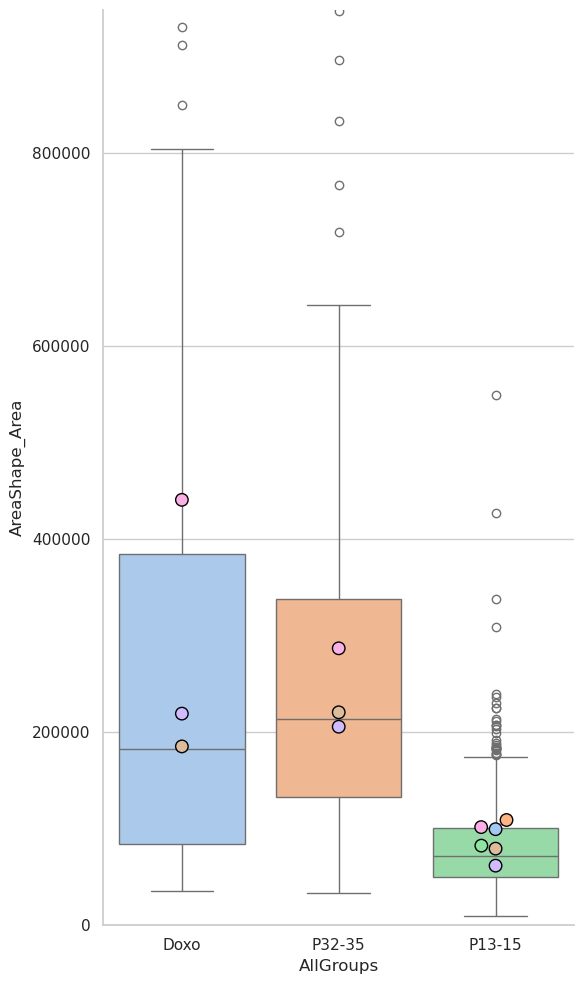

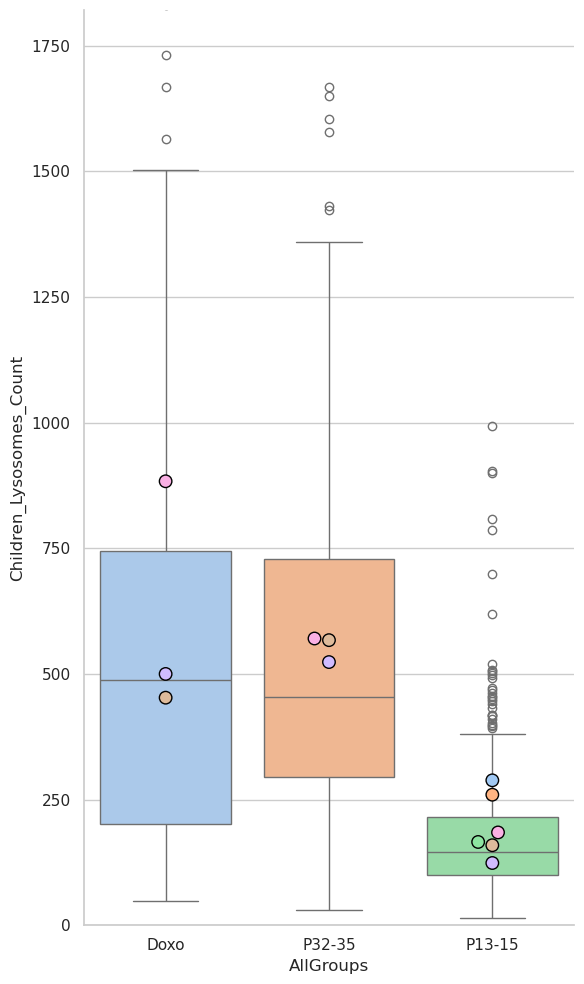

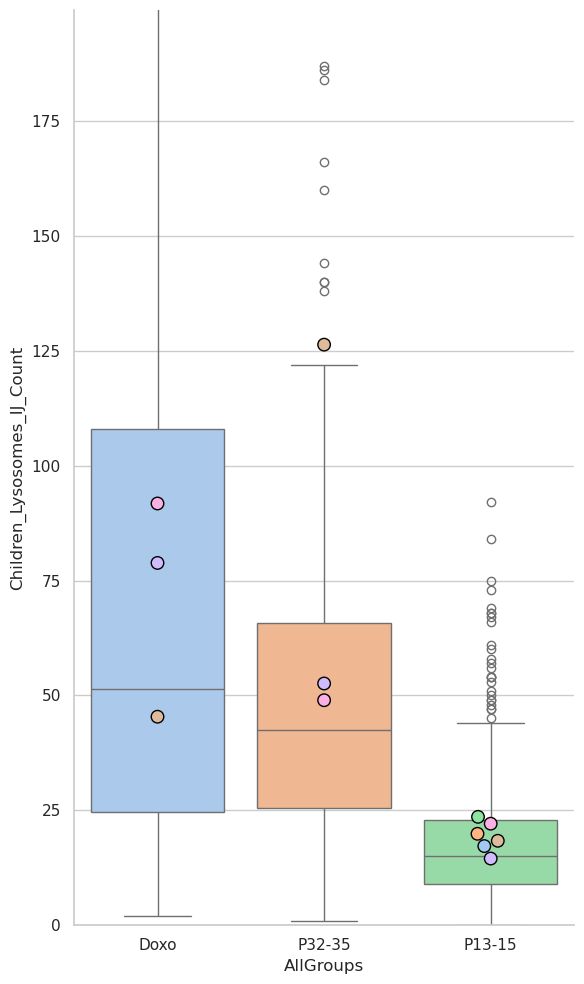

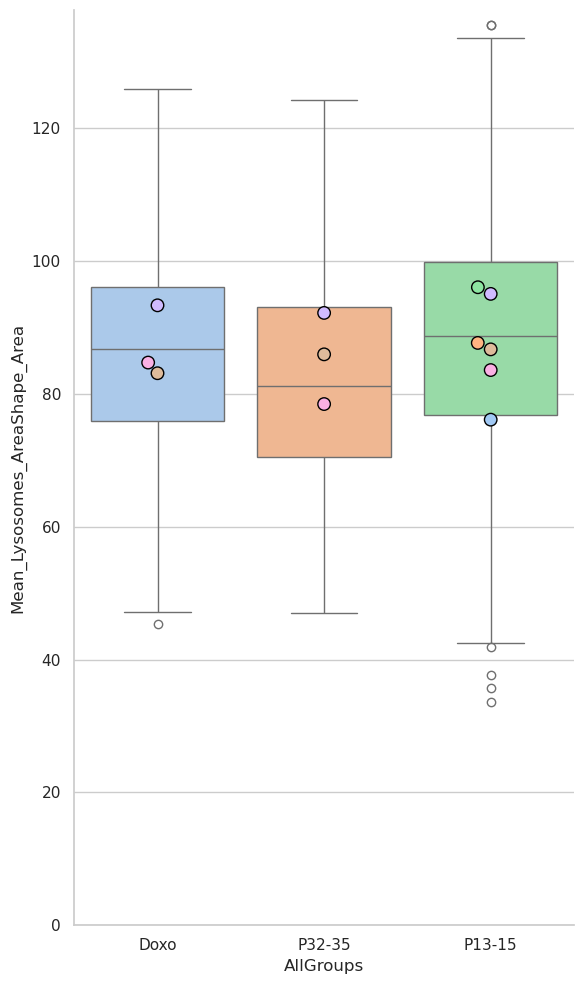

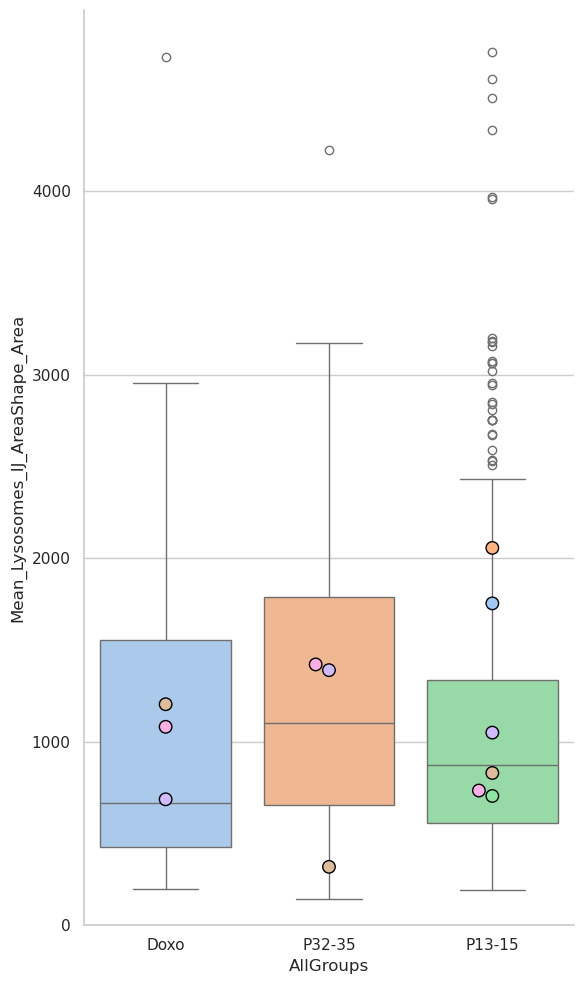

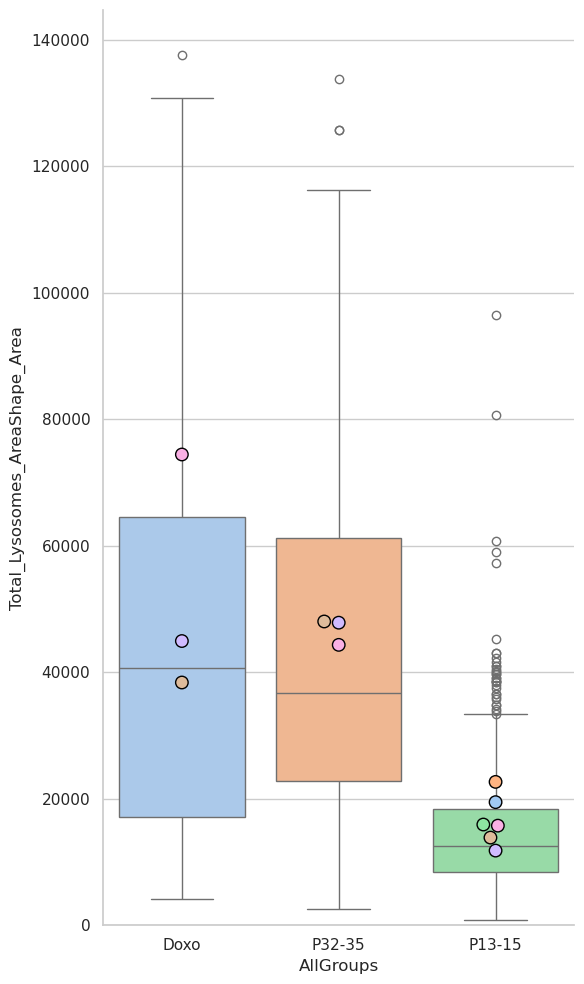

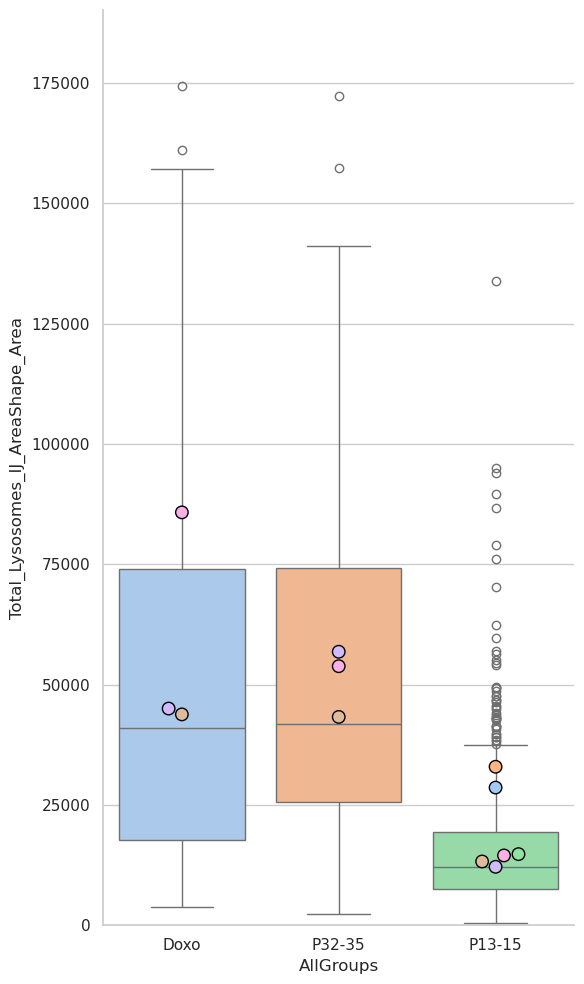

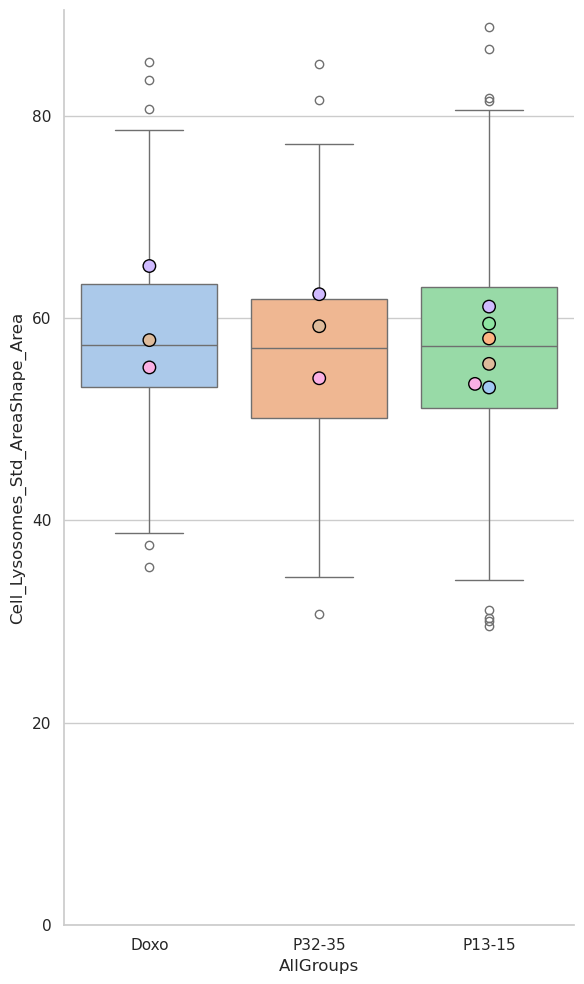

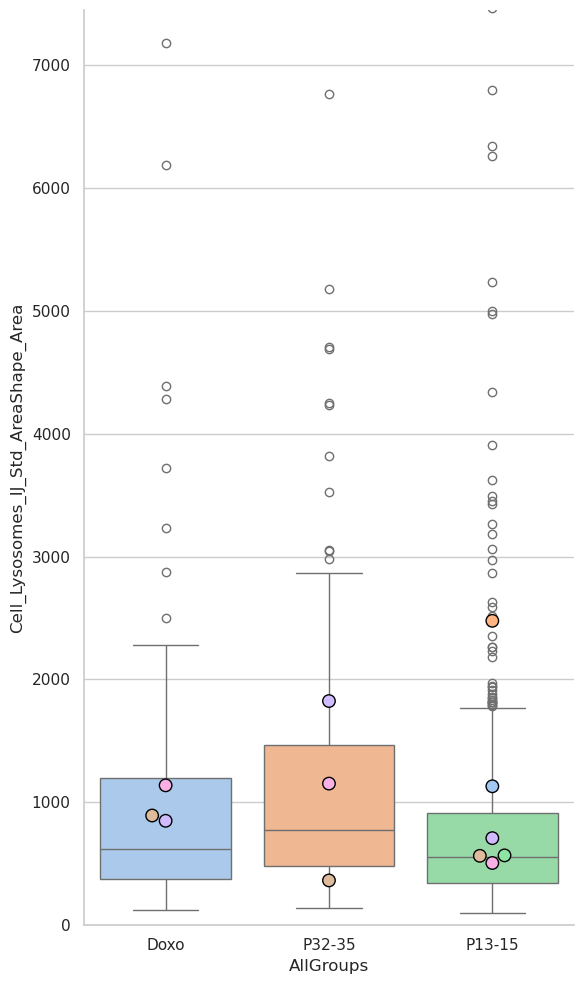

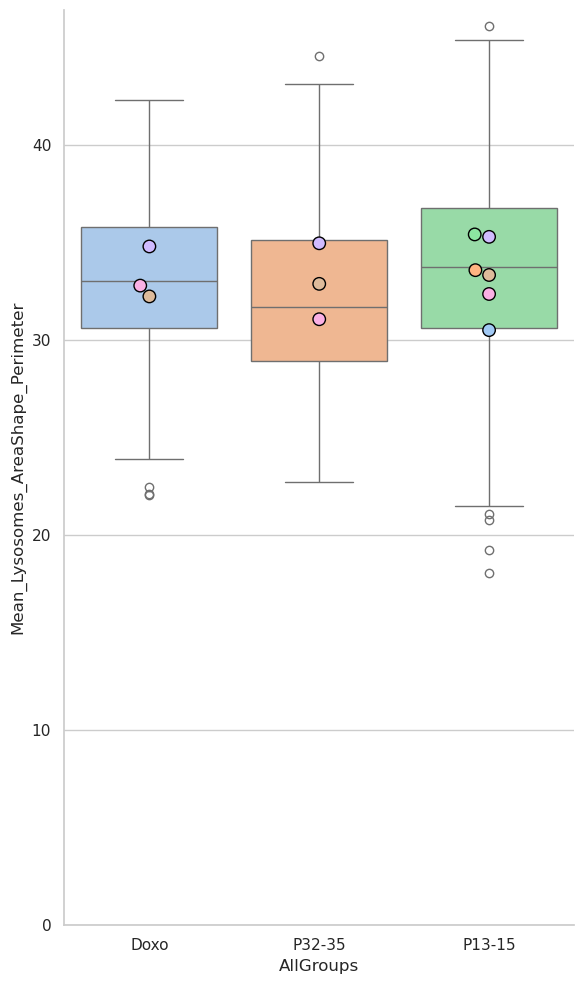

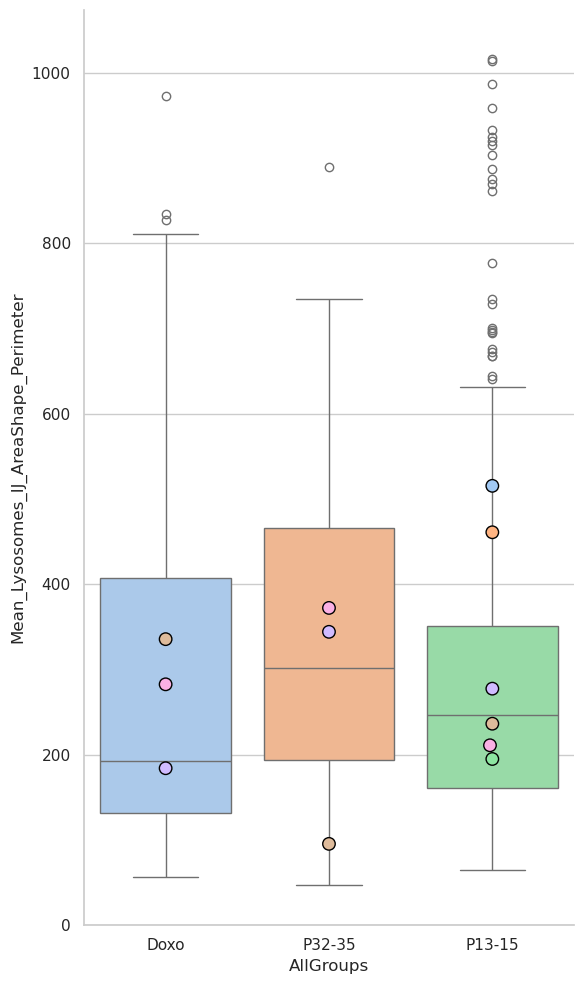

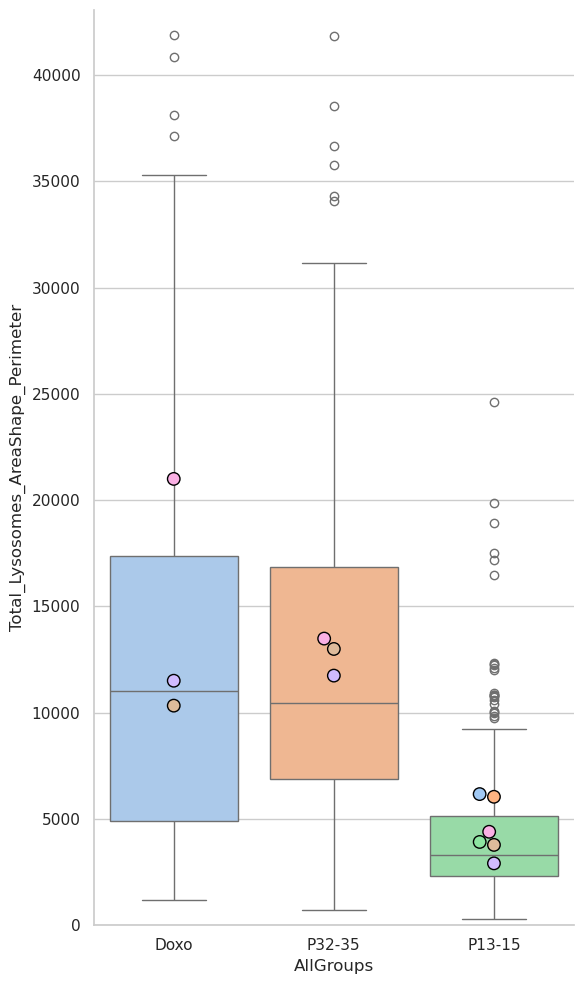

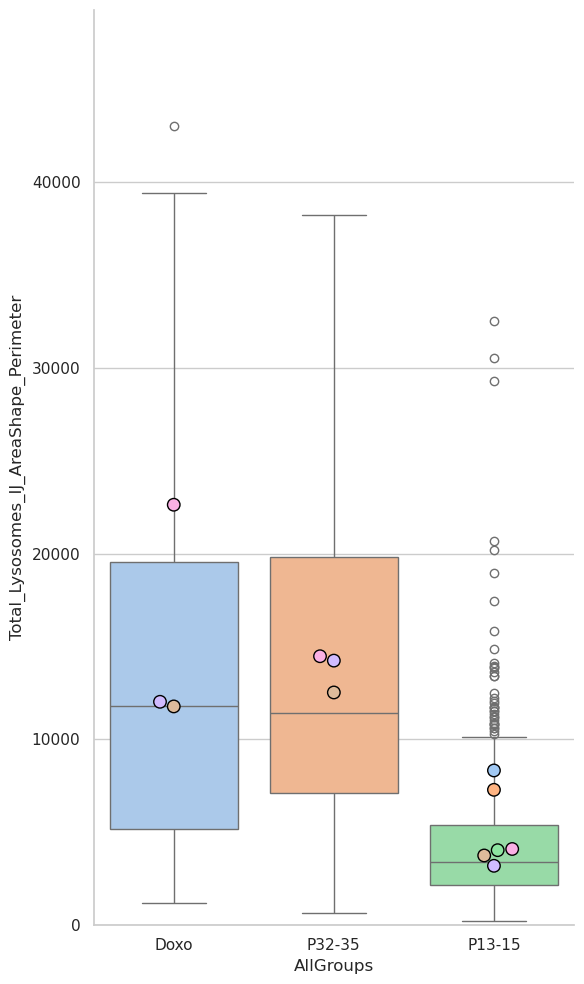

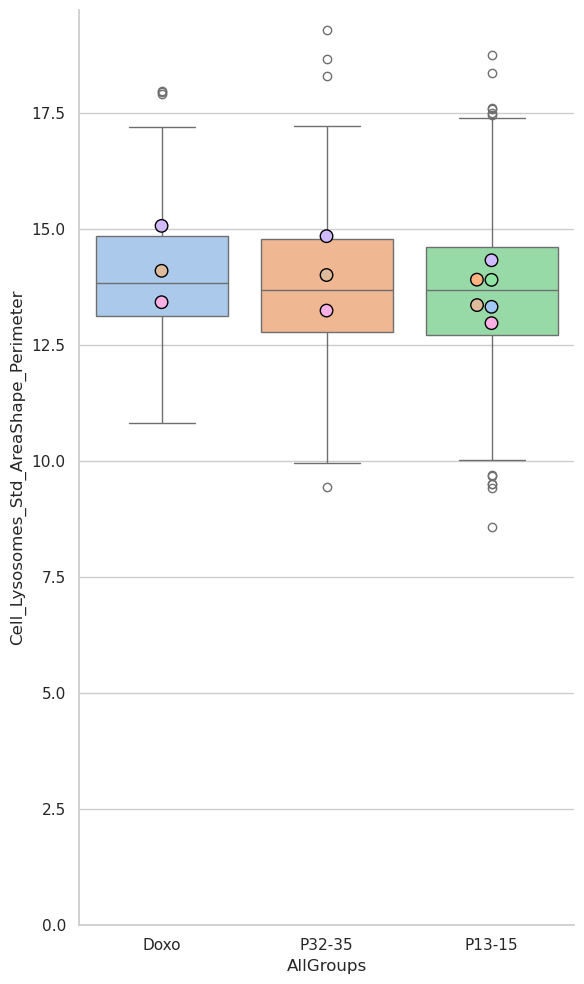

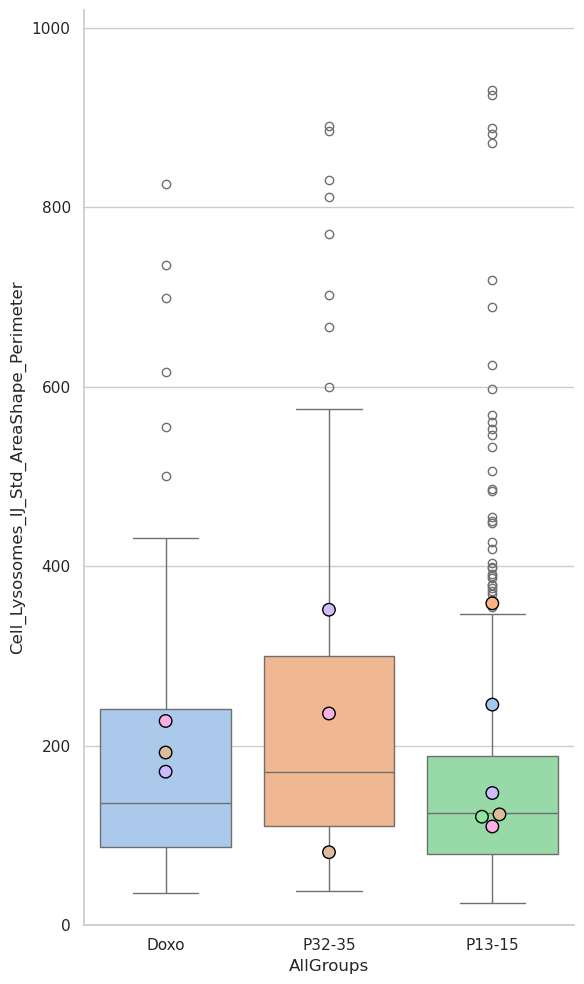

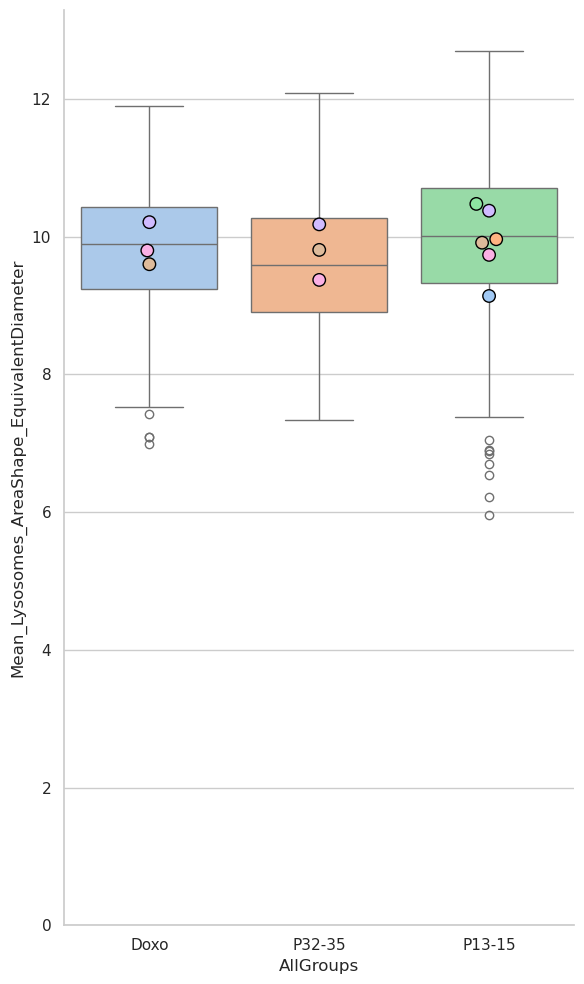

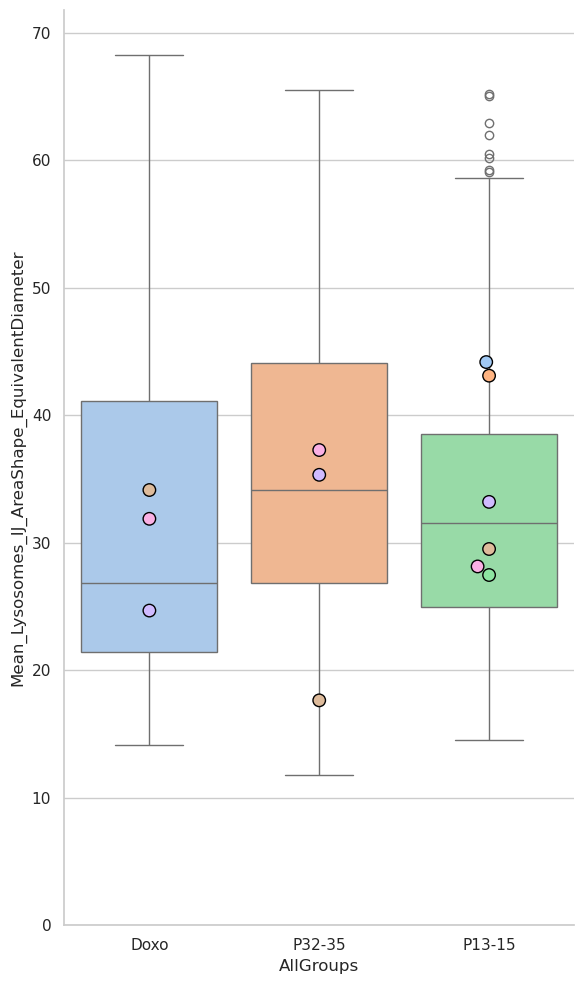

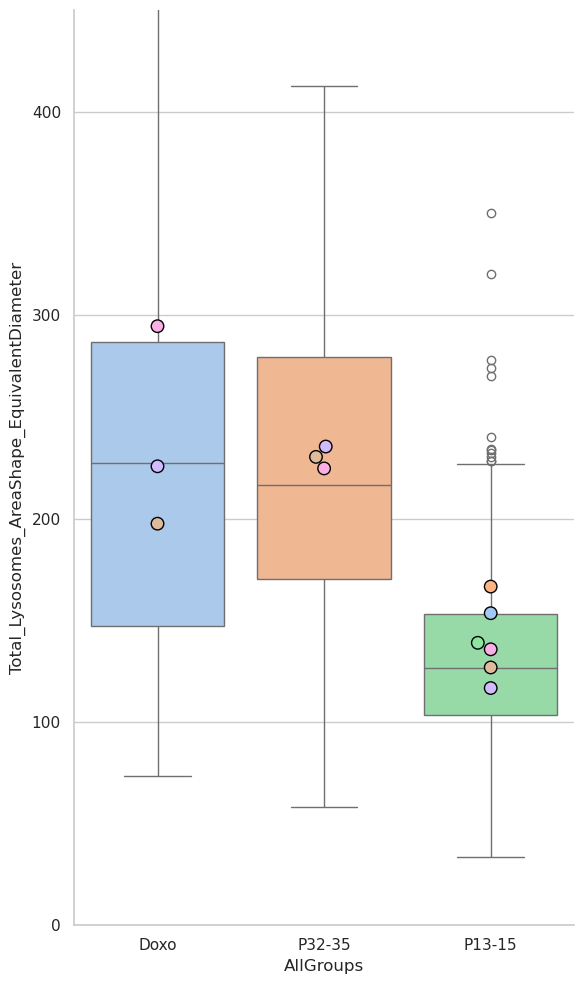

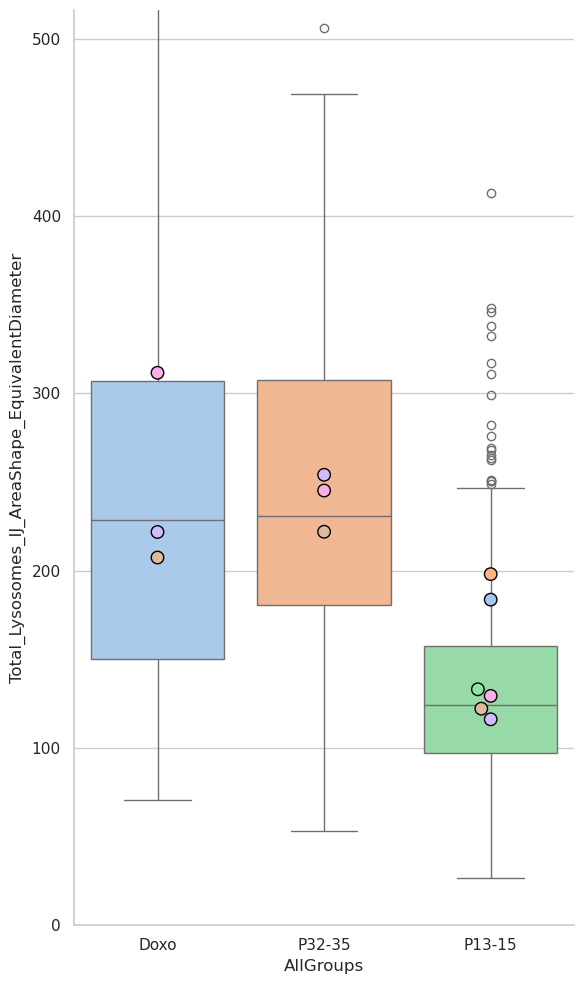

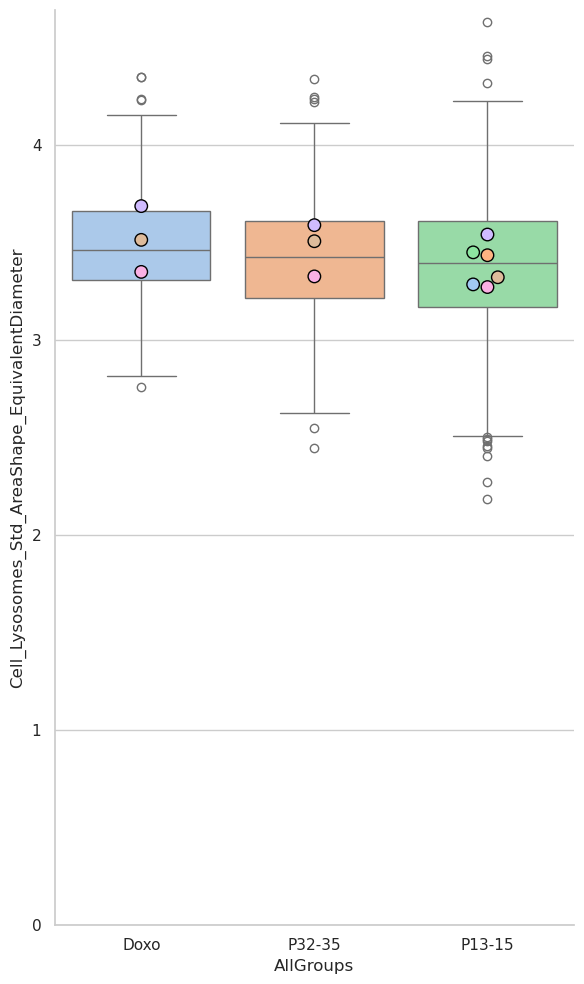

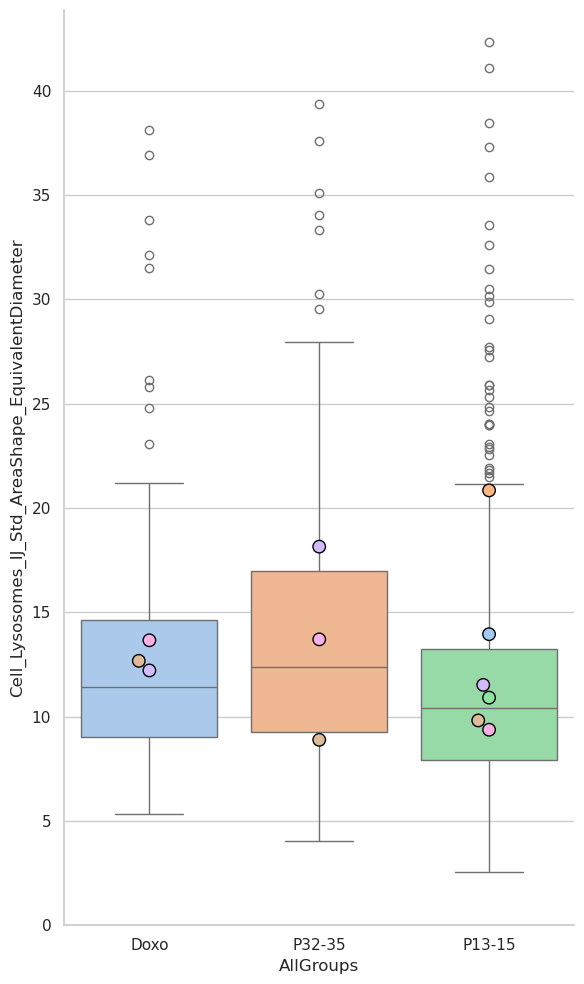

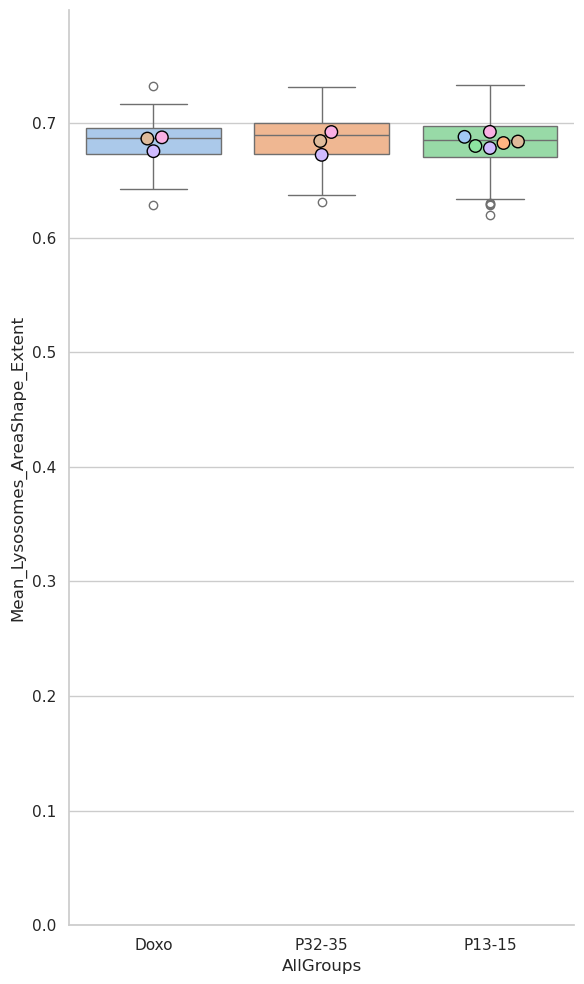

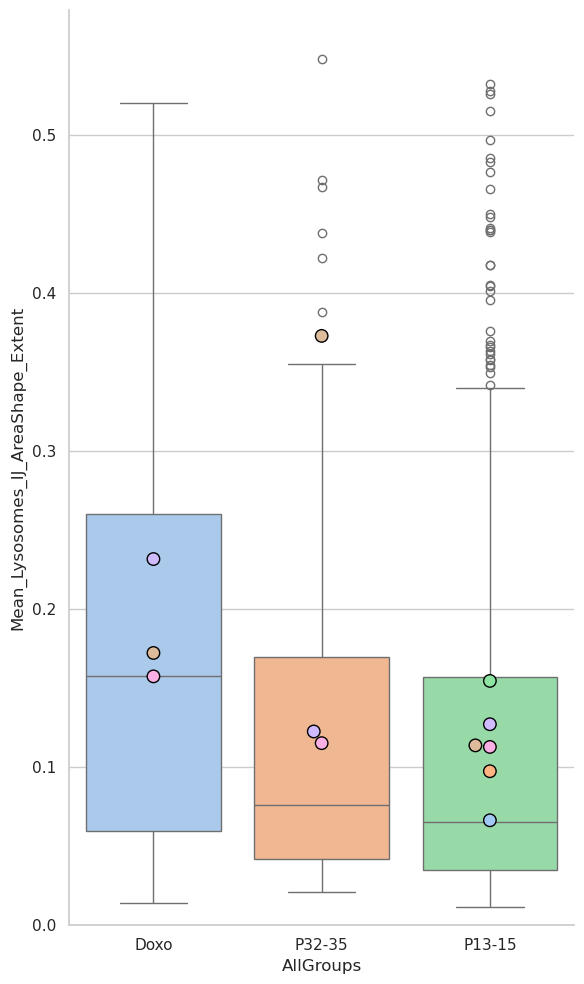

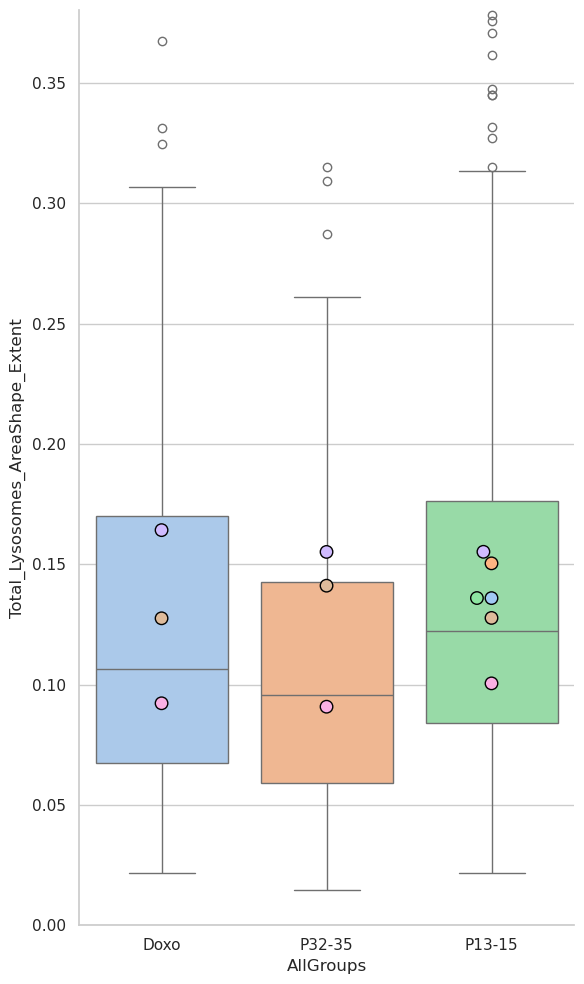

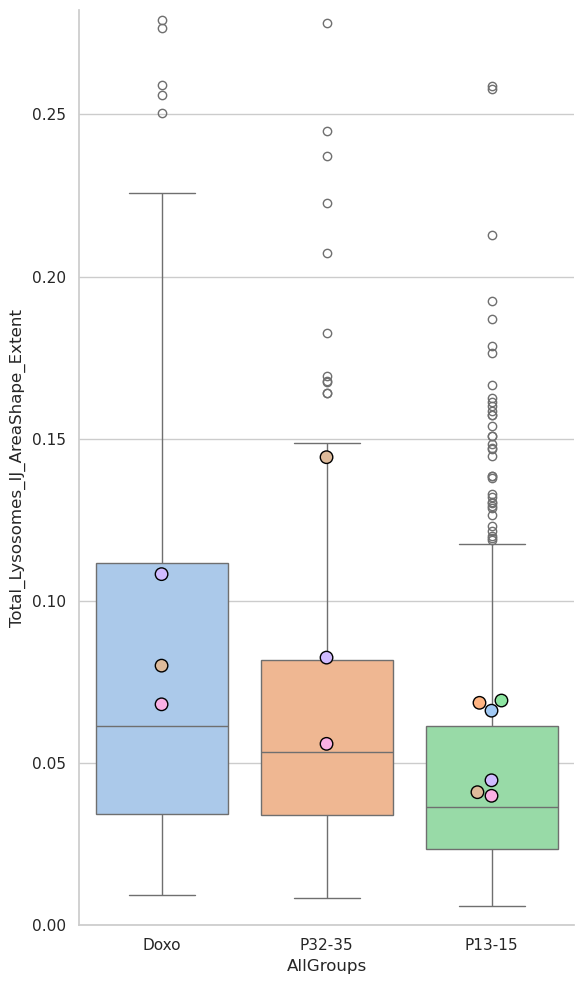

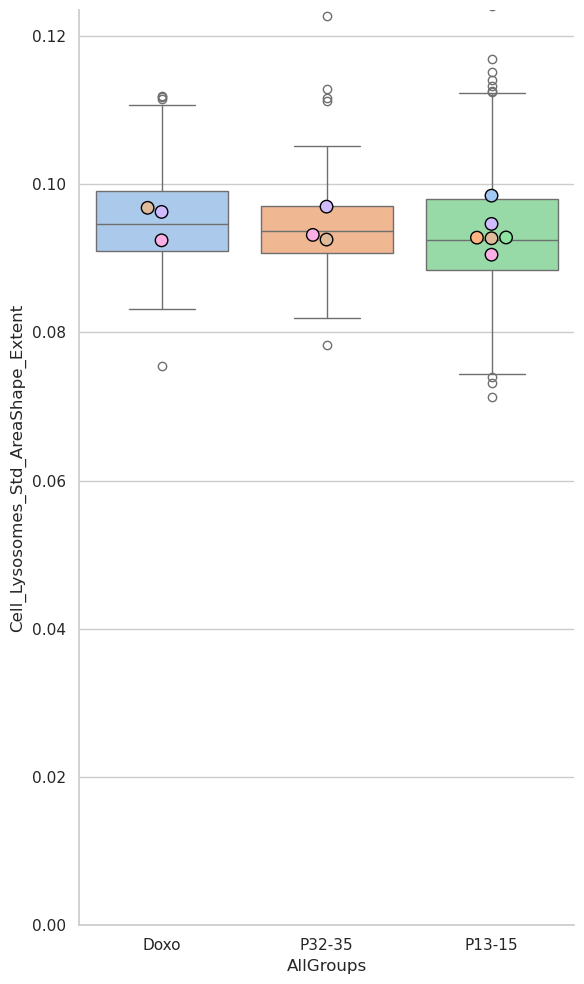

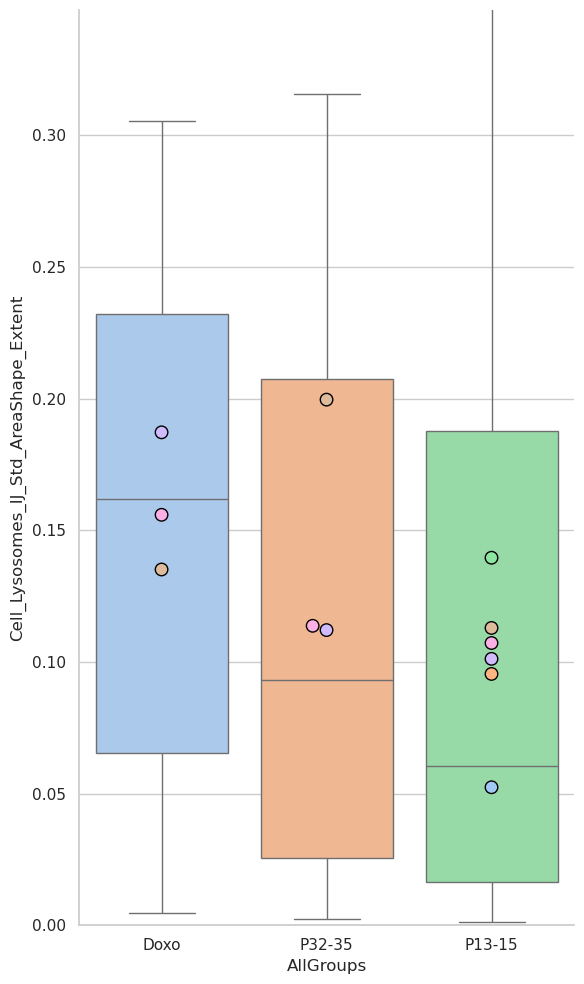

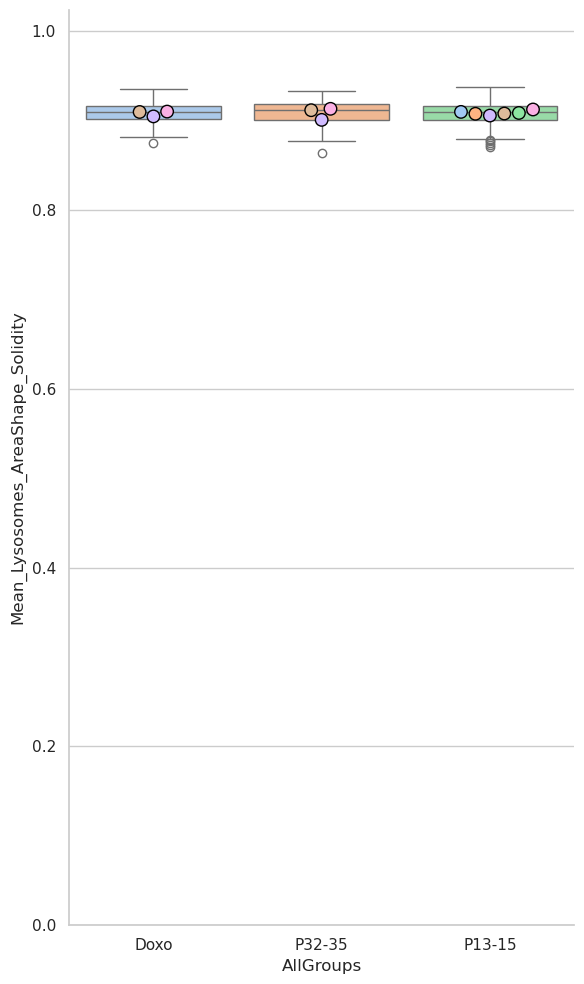

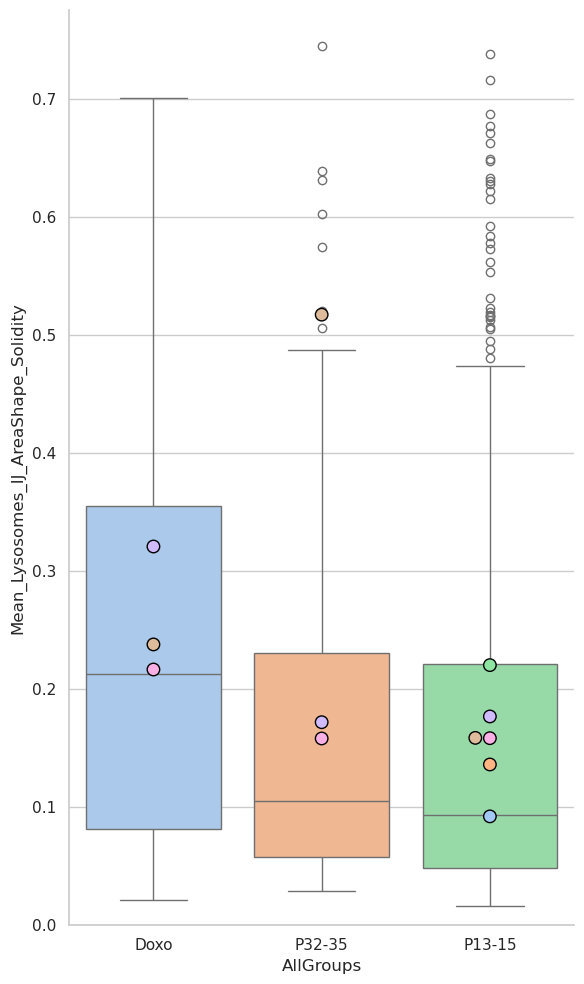

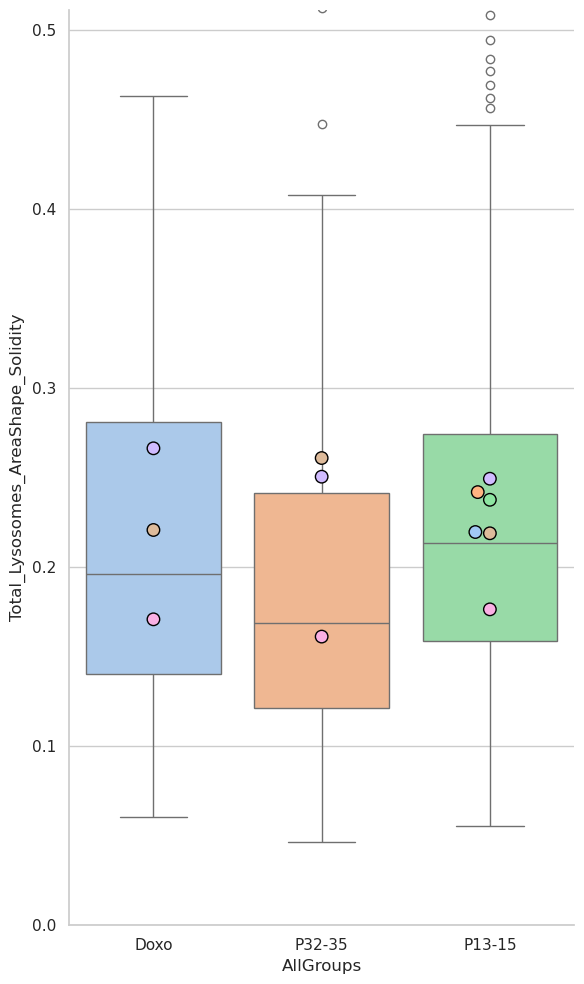

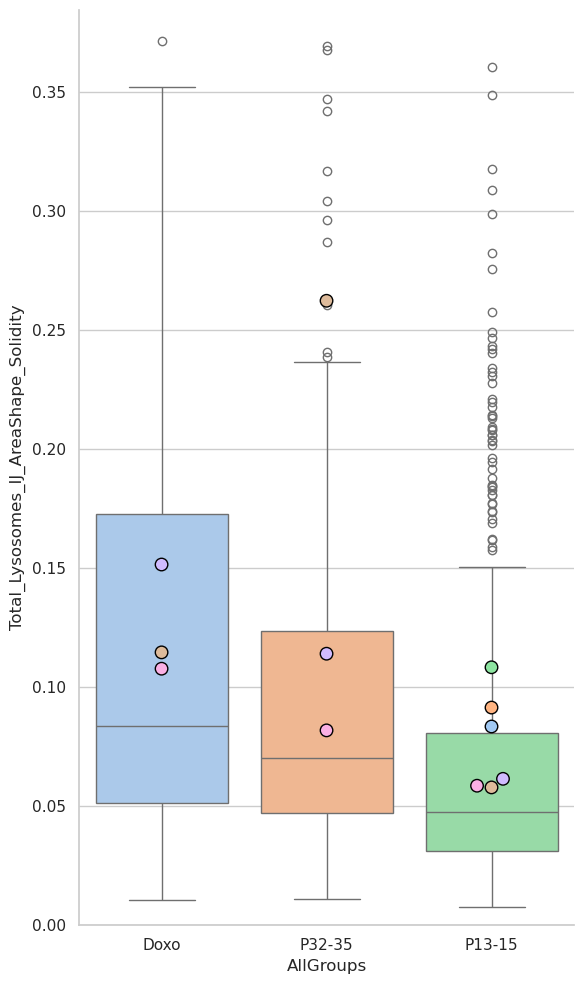

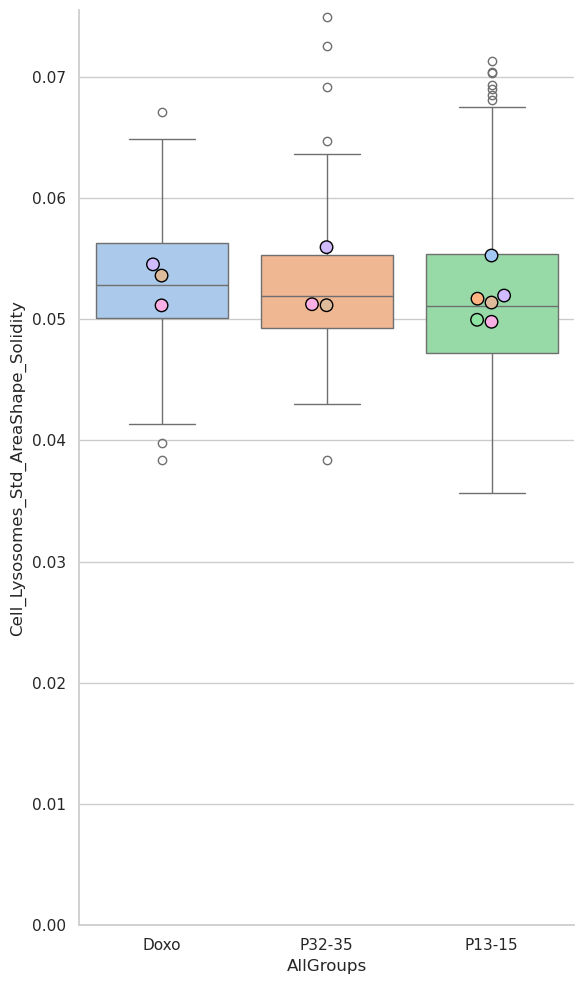

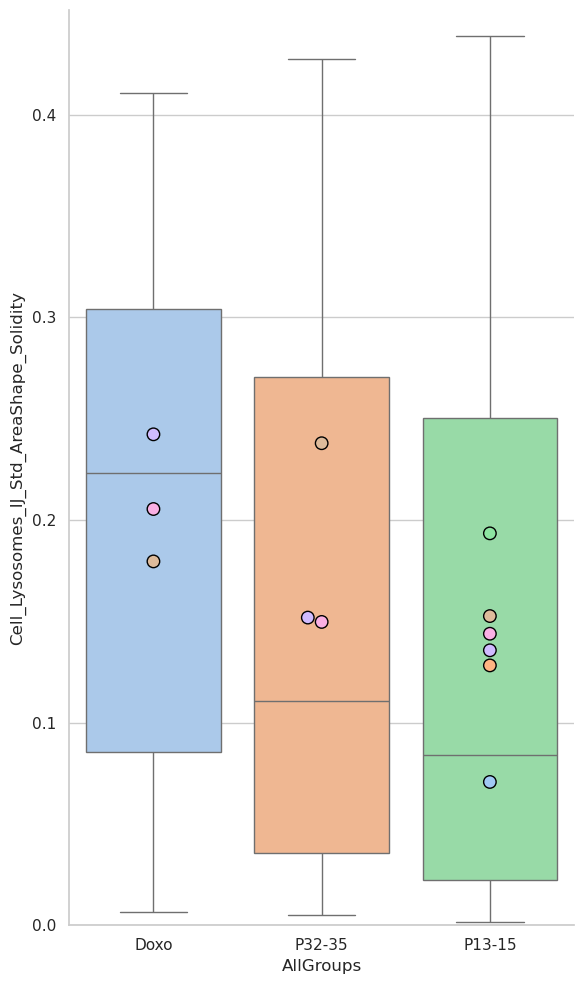

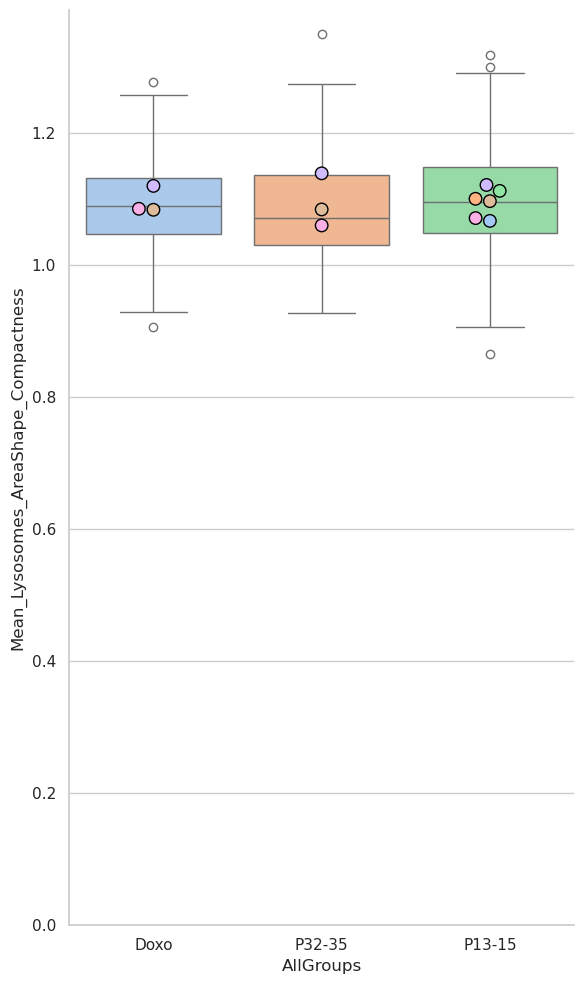

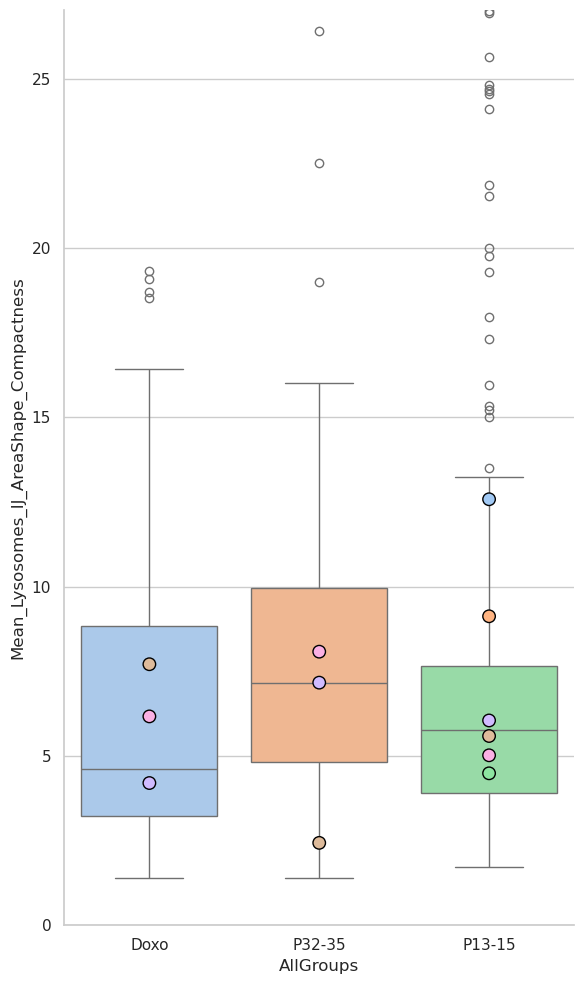

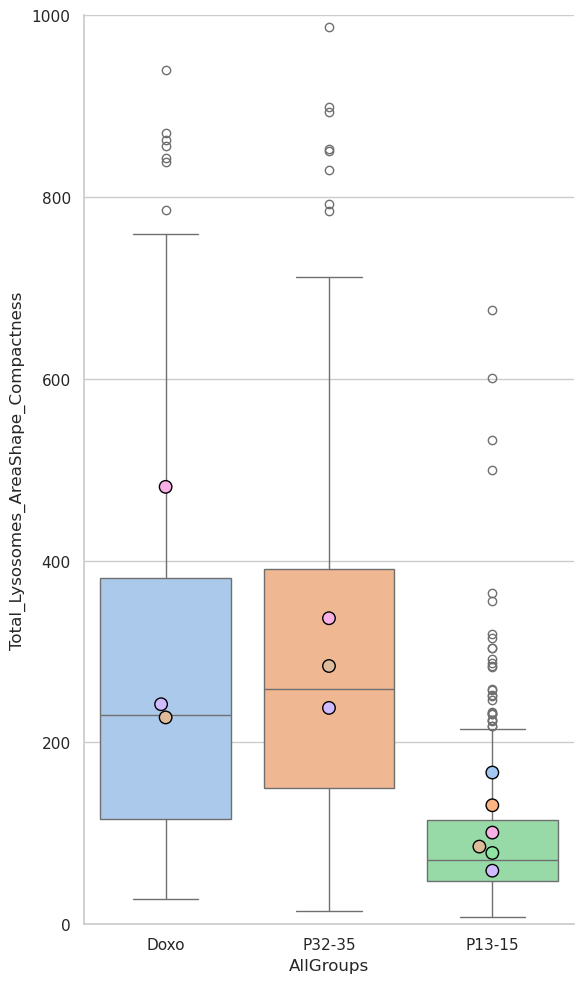

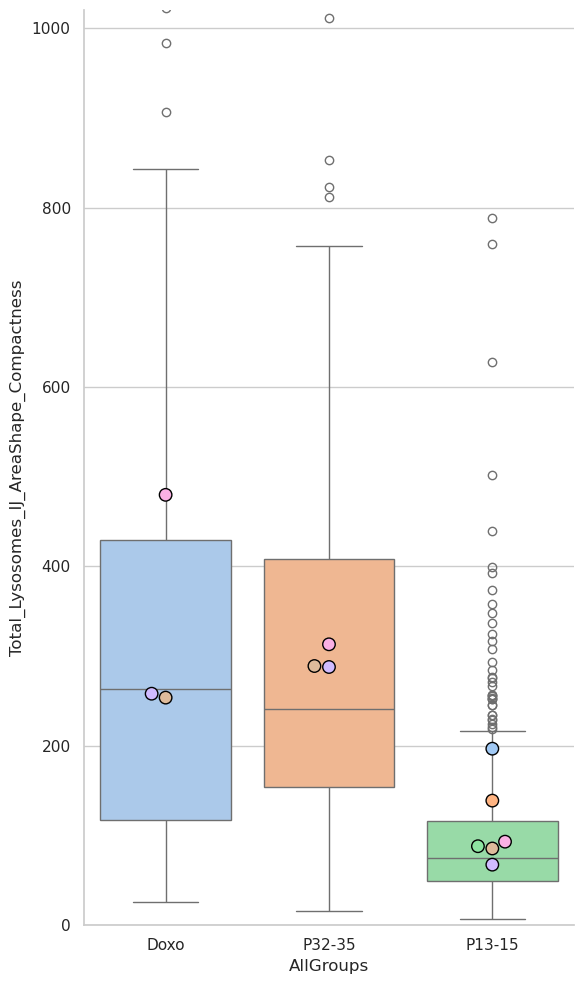

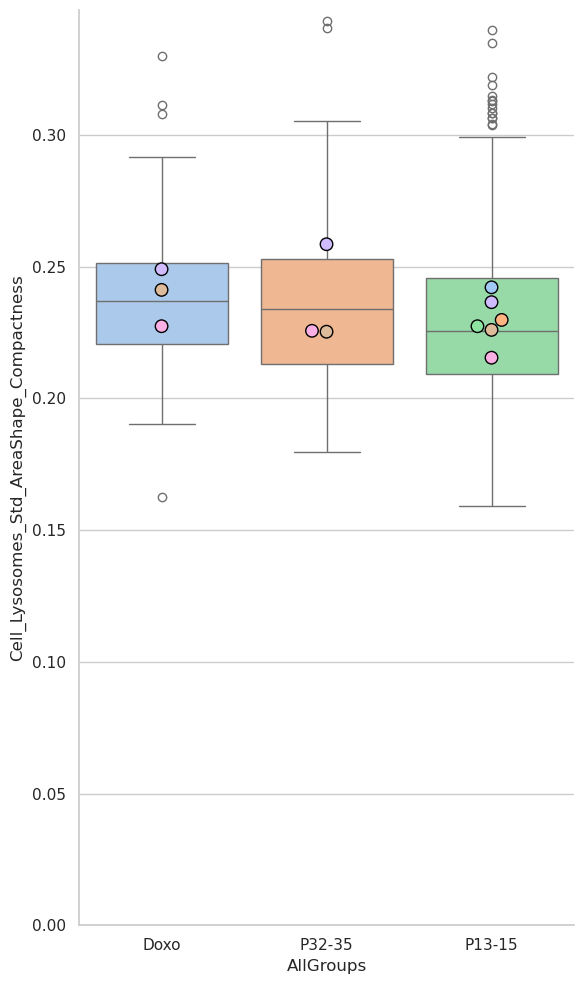

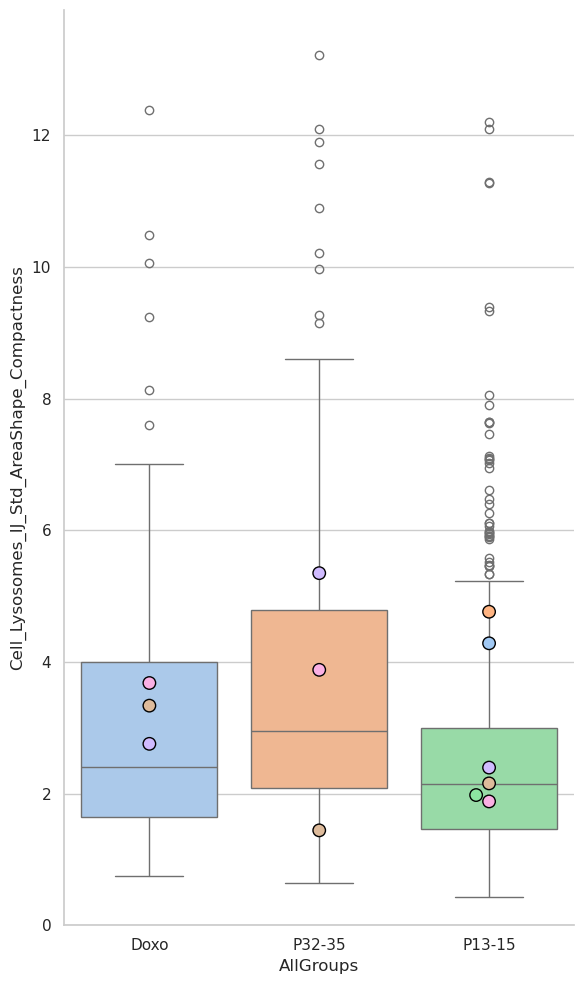

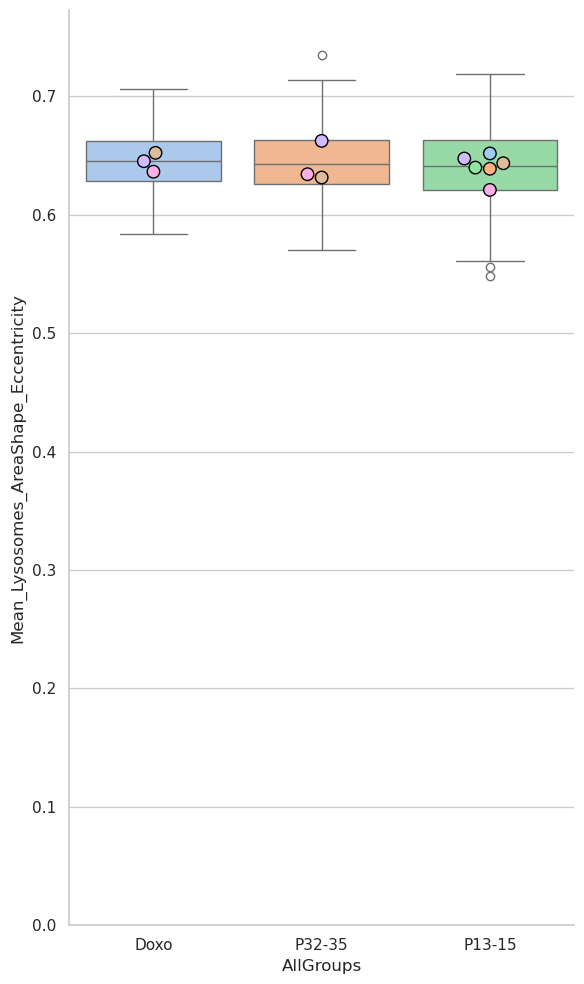

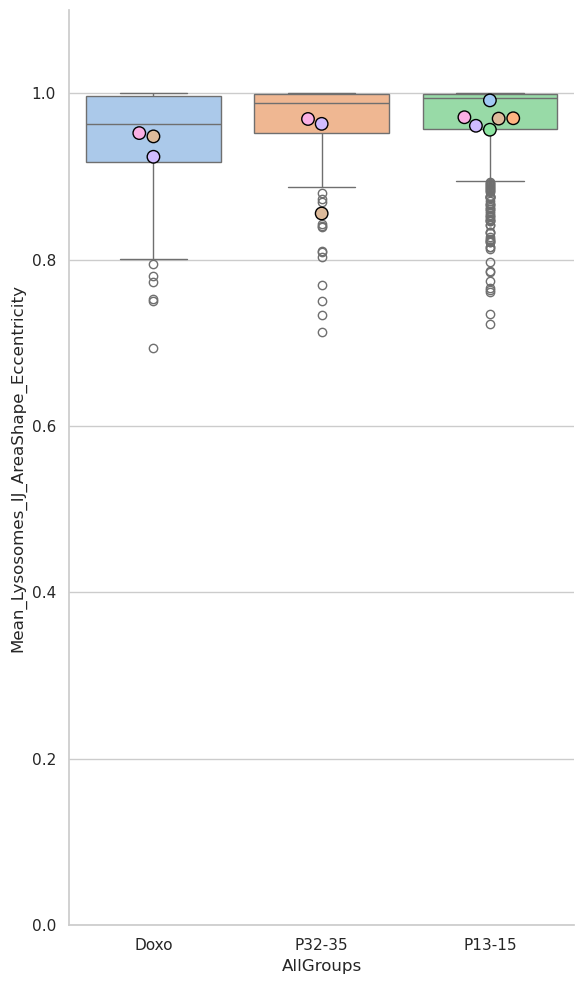

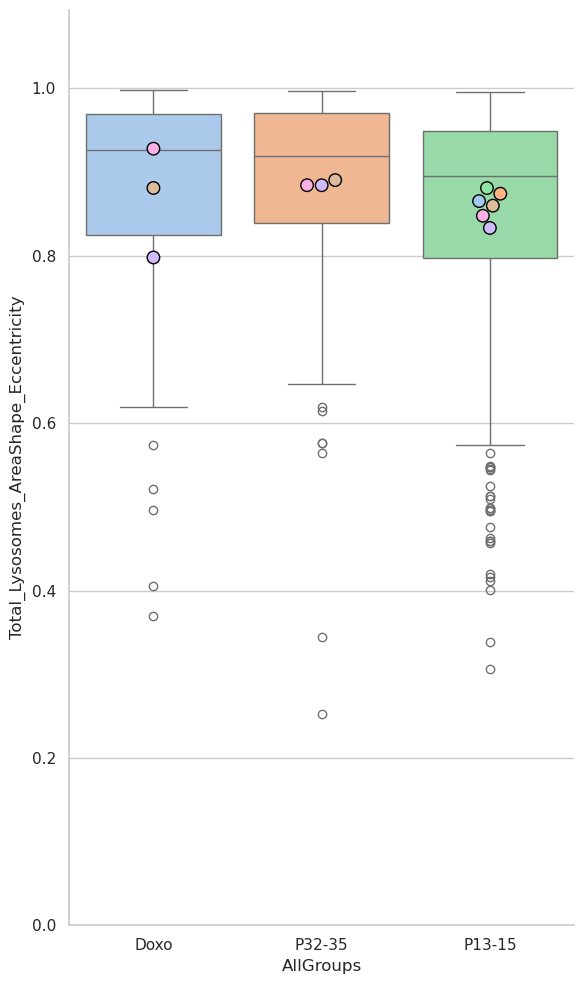

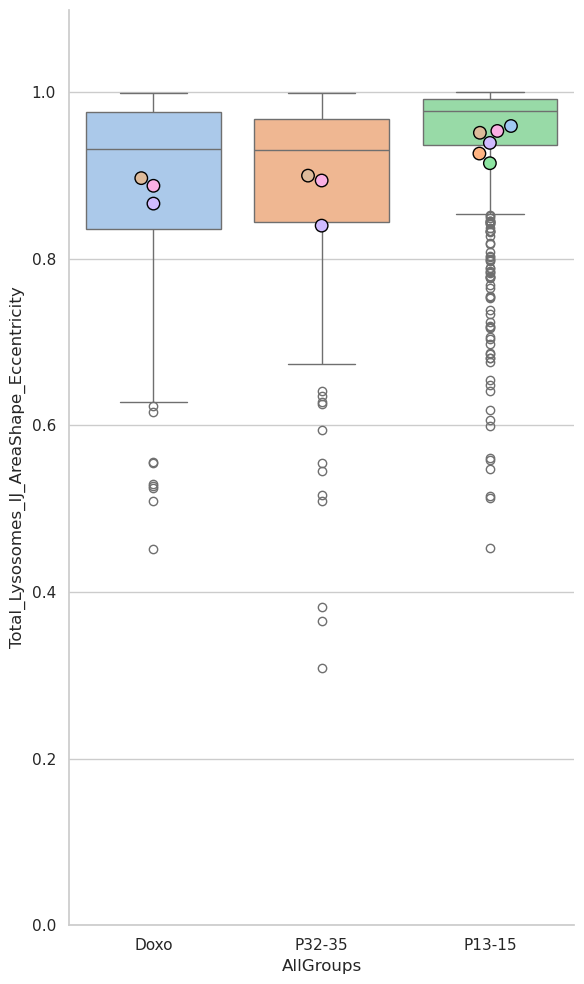

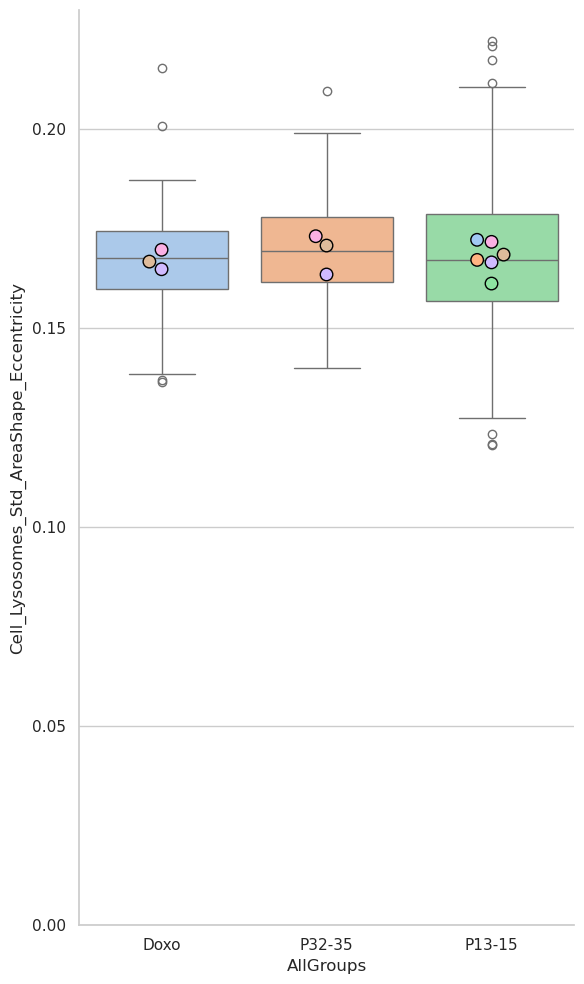

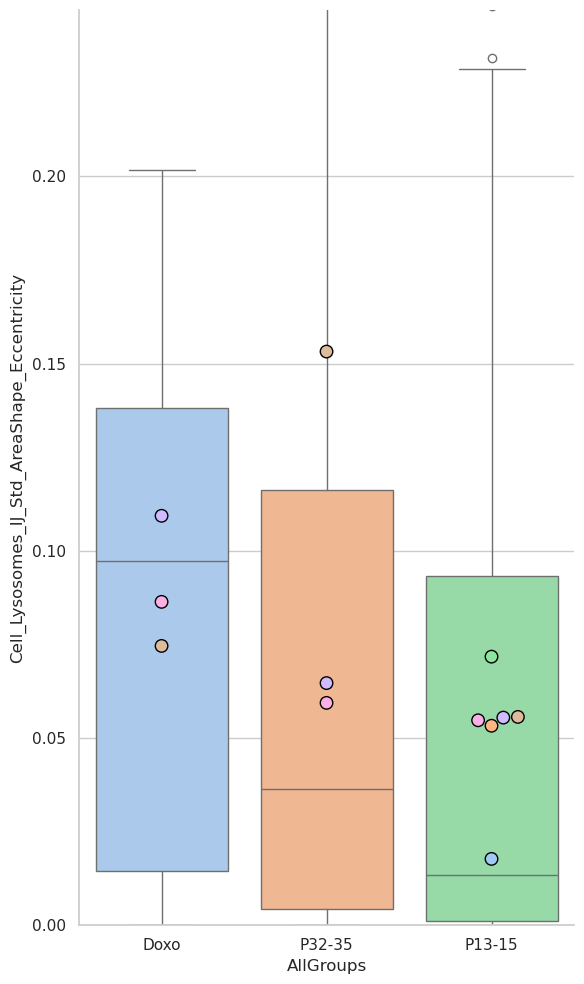

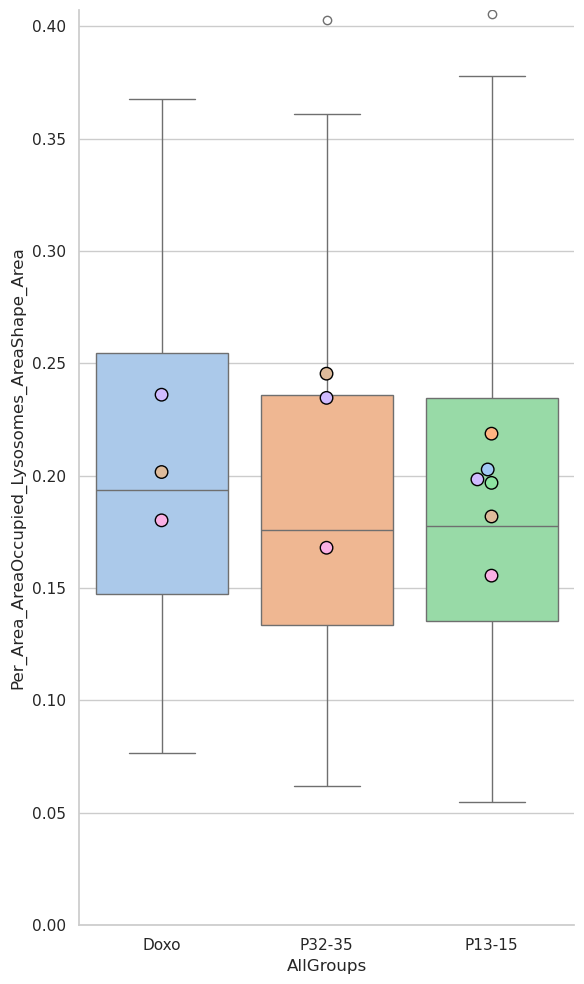

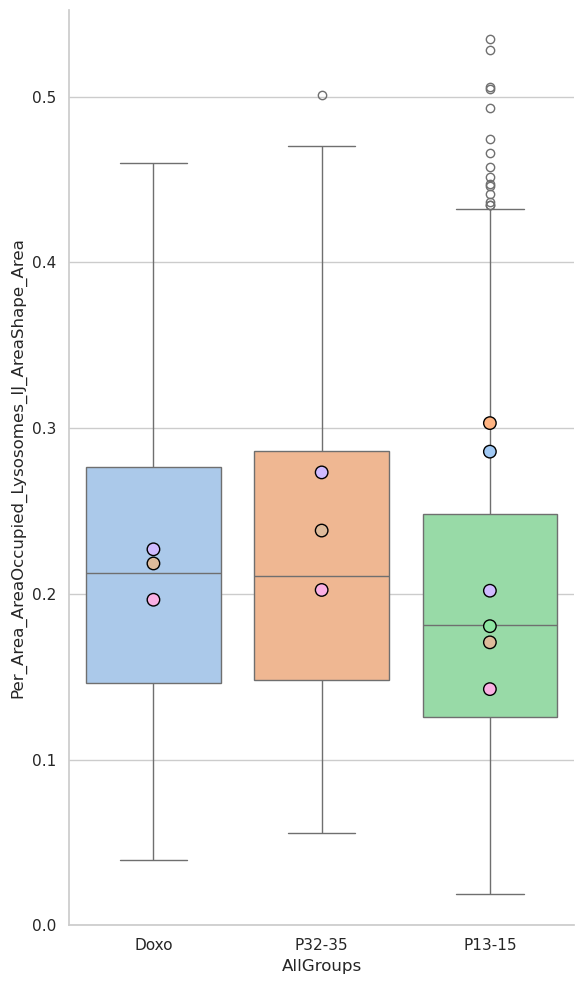

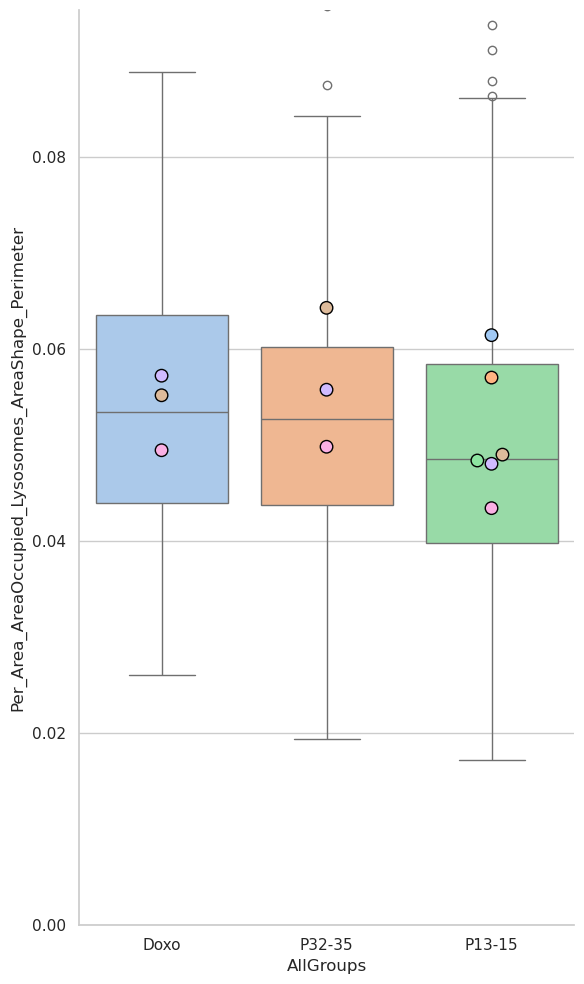

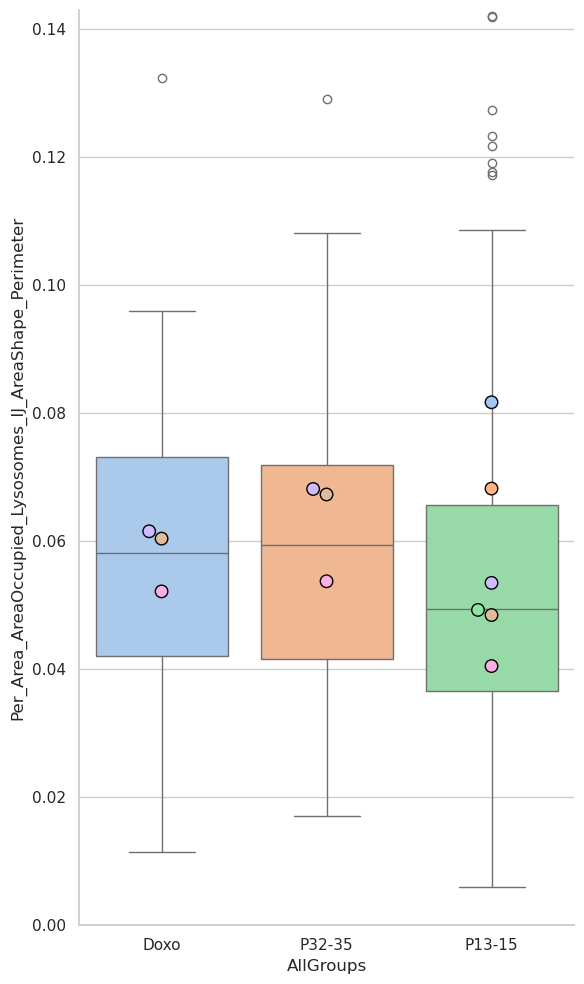

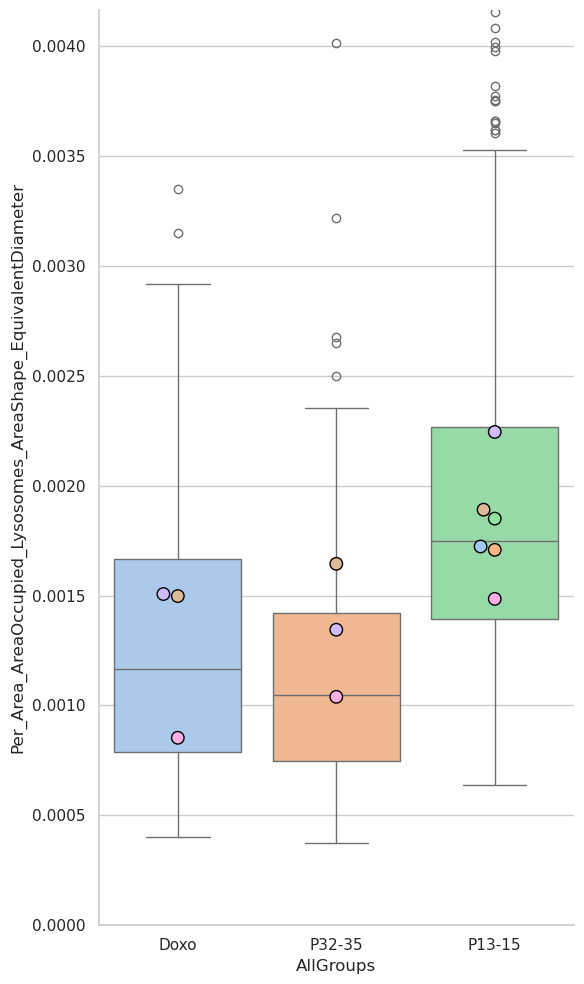

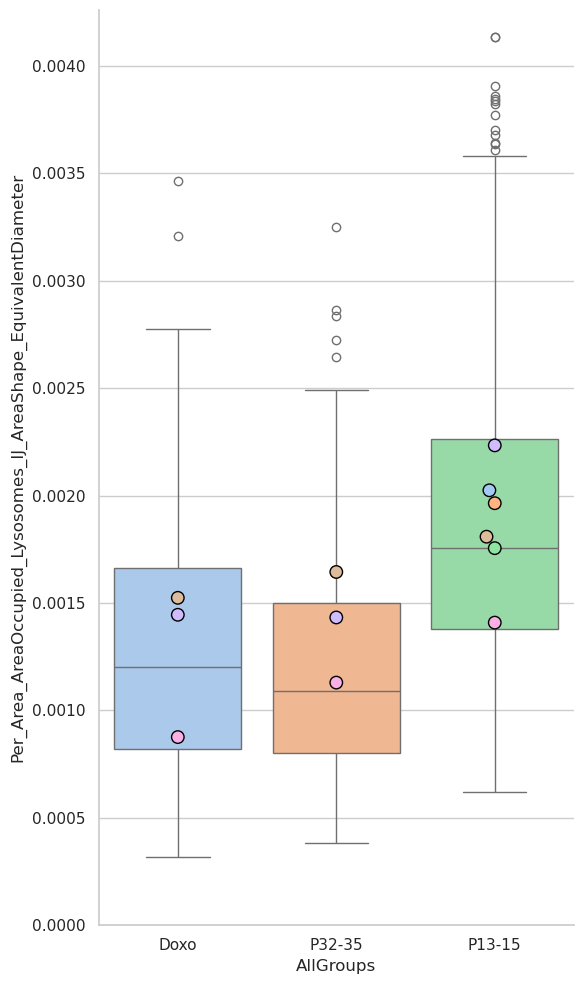

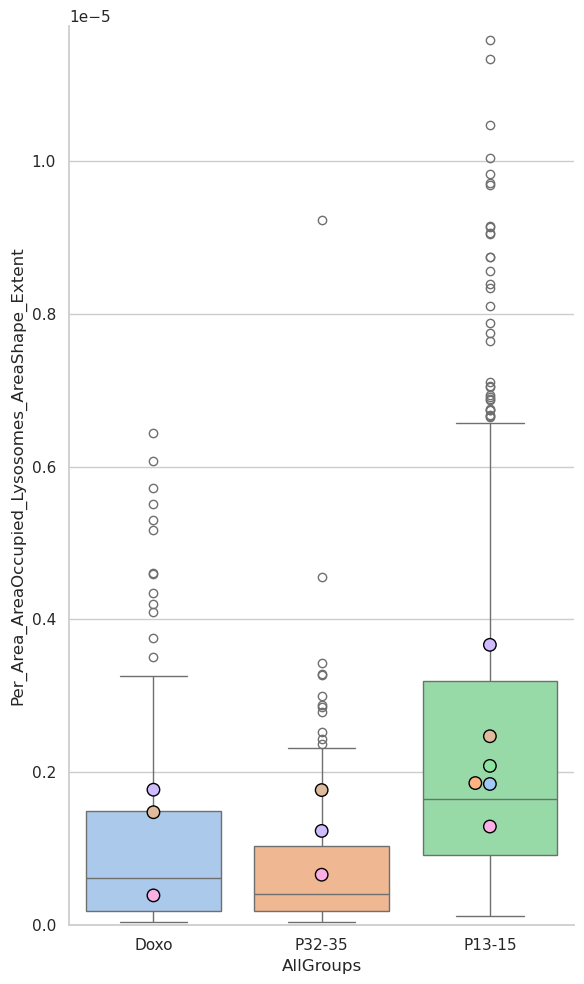

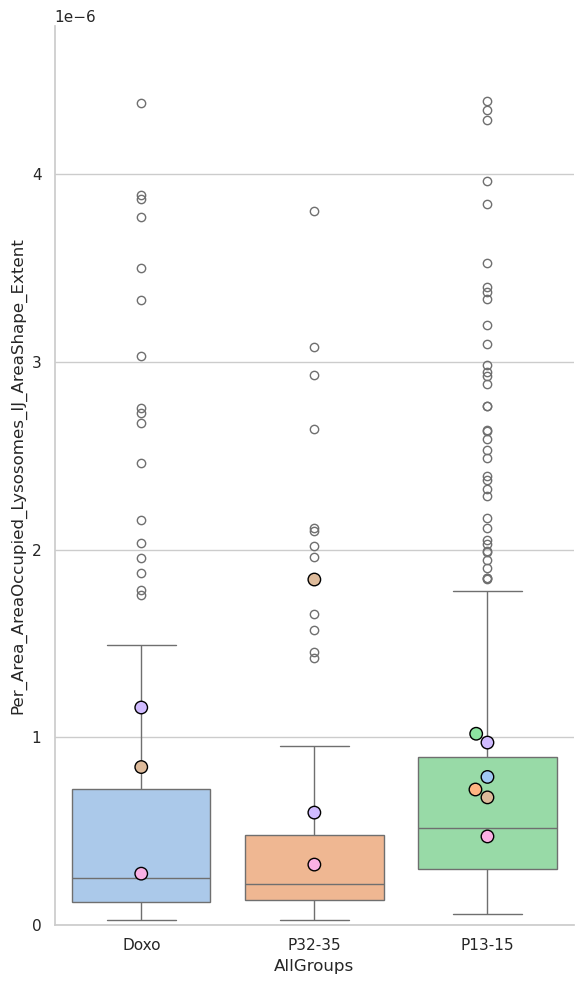

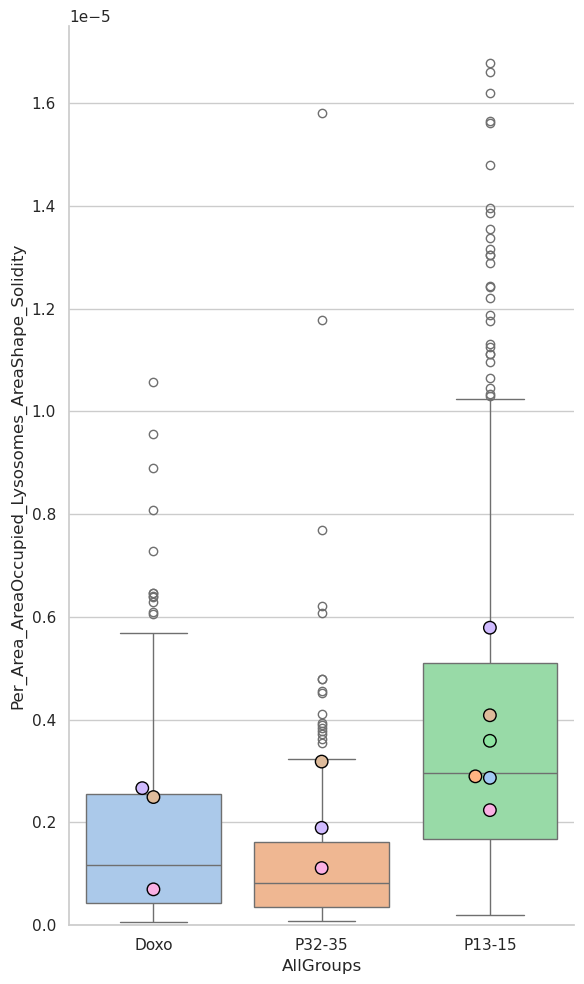

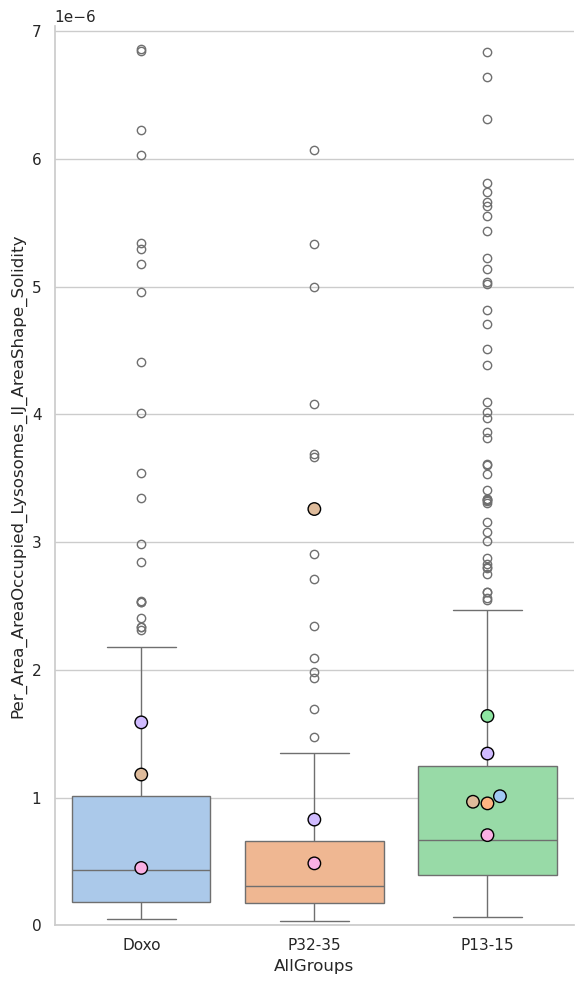

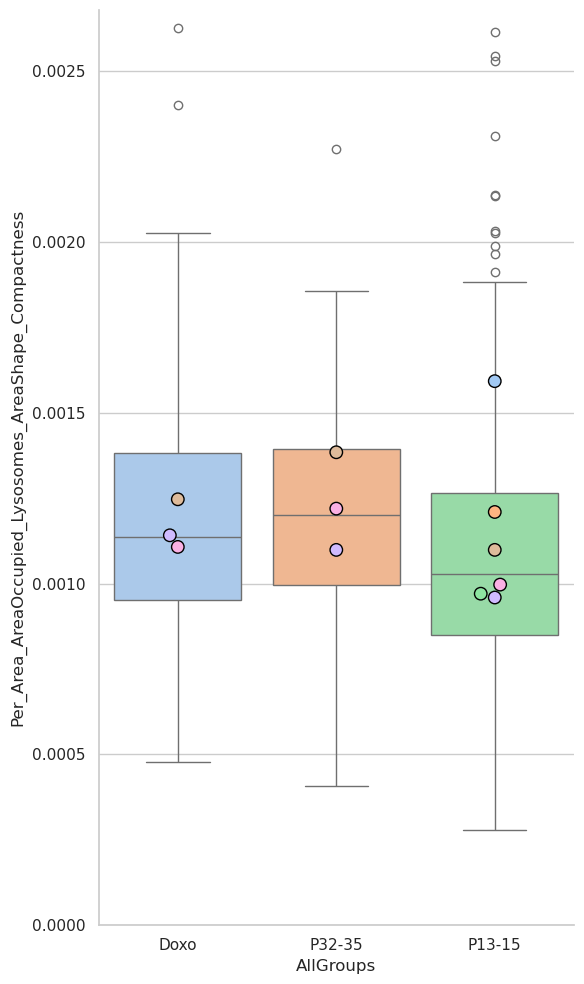

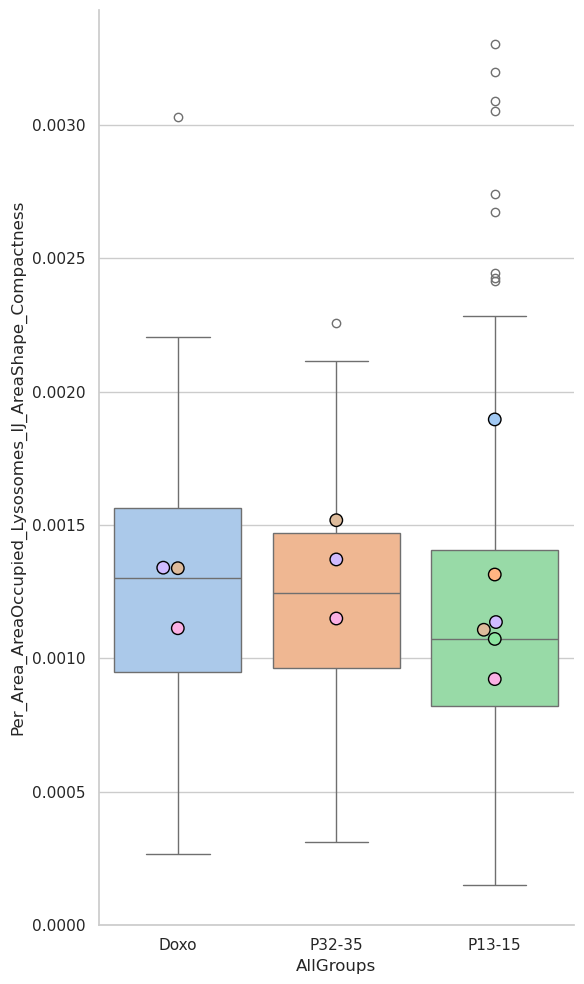

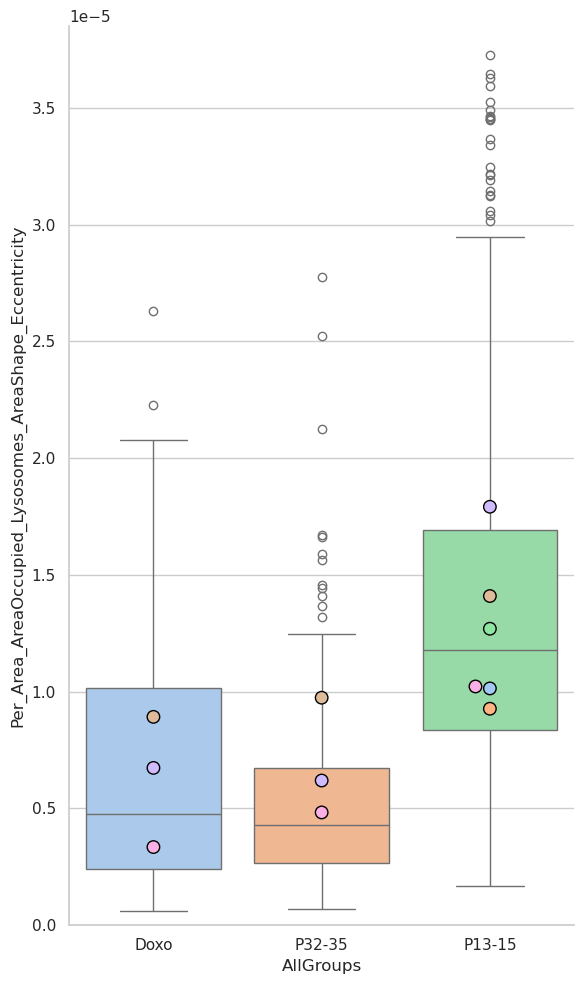

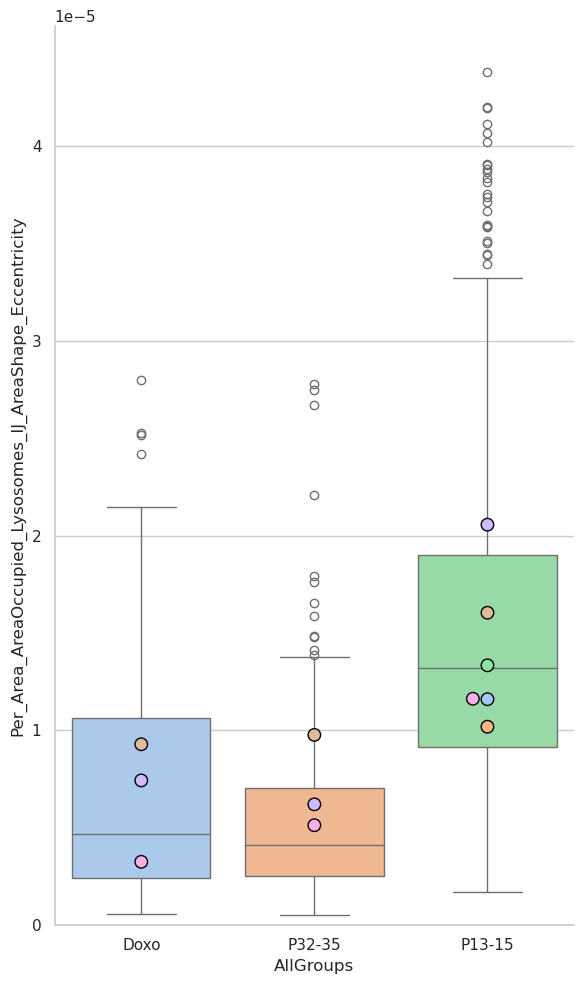

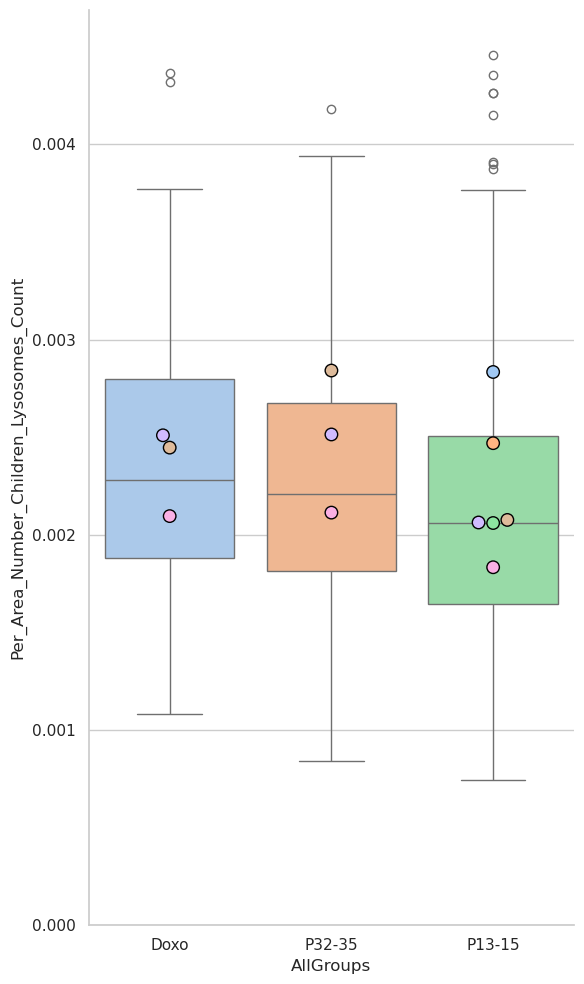

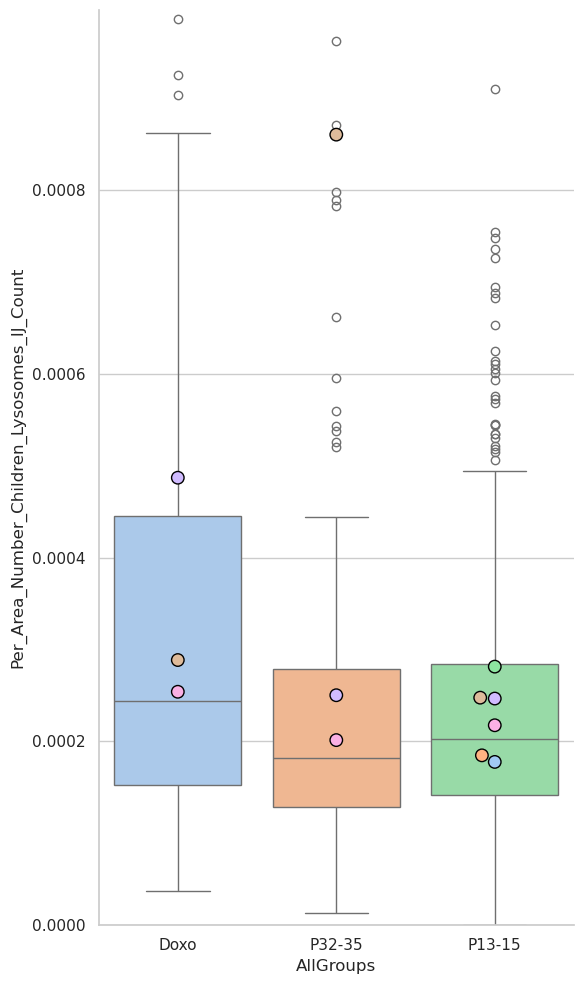

In [ ]:


feature_cols = use_cols_new_unique[3:]
colour_dict = get_hard_code_plate_colours(
    combined_cell_df_mitolyso_2, ["1", "2", "3", "4", "5", "6", "7"], "Metadata_PlateNumber"
)

        
# def plot_boxplots_with_swarm_pairs(
#     display_df,
#     display_df_pivot_plates,
#     feature_cols,
#     colour_dict=colour_dict,
#     size=(6, 10),
# ):
#     outpath = "segmentation_test/pairedplots"
#     os.makedirs(outpath, exist_ok=True)
#     for col in feature_cols:
#         fig, axes = plt.subplots(1, 2, figsize=(figsize[0] * 2, figsize[1]), sharey=True)

#         for ax, suffix in zip(axes, ["1", "2"]):
#             item = rows[suffix]
#         sns.set_style("whitegrid")
#         sns.set_context("notebook")
#         ax = plt.gca()
#         ax = sns.boxplot(
#             display_df,
#             x="AllGroups",
#             y=col,
#             palette="pastel",
#             fill=True,
#             hue="AllGroups",
#             legend=False,
#         )
#         sns.swarmplot(
#             display_df_pivot_plates,
#             x="AllGroups",
#             y=col,
#             palette=colour_dict,
#             hue="Metadata_PlateNumber",
#             dodge=False,
#             size=9,
#             legend=False,
#             linewidth=1,
#             edgecolor="k",
#         )
#         sns.despine()
#         plt.ylim(0, np.percentile(display_df[col].dropna(), 99) * 1.1)
#         plt.tight_layout()
#         plt.savefig(os.path.join(outpath, f"{col}_boxplot.png"))
#         plt.show()

plot_boxplots_with_swarm(display_df, display_df_pivot_plates, feature_cols, colour_dict, size=(6, 10))

In [ ]:
def plot_boxplots_with_swarm_tukey(
    display_df,
    display_df_pivot_plates,
    feature_cols,
    colour_dict=colour_dict,
    size=(6, 10),
    order=None,
    group_col="AllGroups",
    plate_col="Metadata_PlateNumber",
):
    outpath = "segmentation_test/plots_tukey"
    os.makedirs(outpath, exist_ok=True)
    from statannotations.Annotator import Annotator

    if order is None:
        order = display_df[group_col].dropna().unique().tolist()

    for col in feature_cols:
        plt.figure(figsize=size)
        sns.set_style("whitegrid")
        sns.set_context("talk")
        ax = sns.boxplot(
            data=display_df,
            x=group_col,
            y=col,
            palette="pastel",
            fill=True,
            hue=group_col,
            legend=False,
        )
        sns.swarmplot(
            data=display_df_pivot_plates,
            x=group_col,
            y=col,
            palette=colour_dict,
            hue=plate_col,
            dodge=False,
            size=9,
            legend=False,
            linewidth=1,
            edgecolor="k",
        )

        pairs = getpairs(display_df, group_col, order=order)
        pairs, p_values = pvalues_anova_and_tukeyhsd_posthoc(
            display_df,
            display_df_pivot_plates,
            x_value=group_col,
            y_value=col,
            plate_number_col=plate_col,
            desired_pairs=pairs,
            order=order,
        )

        if pairs:
            annotator = Annotator(
                ax=ax,
                pairs=list(pairs),
                data=display_df,
                plot="boxplot",
                x=group_col,
                y=col,
                order=order,
            )
            annotator.reset_configuration()
            annotator.configure(
                text_format="full",
                test_short_name="tukey_v3",
                pvalue_format_string="{:.4f}",
                fontsize="small",
                loc="inside",
                hide_non_significant=True,
                color="black",
                verbose=2,
                line_height=0.01,
                text_offset=0.5,
                show_test_name=False,
            )
            annotator.set_pvalues_and_annotate(p_values)

        sns.despine()
        if display_df[col].dropna().shape[0] > 0:
            upper = np.nanpercentile(display_df[col].dropna(), 99) * 1.2
            if np.isfinite(upper):
                plt.ylim(0, upper)
        plt.tight_layout()
        plt.savefig(os.path.join(outpath, f"{col}_boxplot_tukey.png"))
        plt.show()
        
plot_boxplots_with_swarm_tukey(
    display_df, display_df_pivot_plates, feature_cols, colour_dict, size=(6, 12)
)


# Define the cell features


## Feature lists here:

In [ ]:
feature_dicts = [mito_features, lyso_features, nuc_features, cell_features]
feature_names = [
    "Mitochondria Features",
    "Lysosome Features",
    "Nucleus Features",
    "Cell Features",
]

# Define the output file path
output_file_path = "allfeatures_file.md"

# Open the file in write mode
with open(output_file_path, "w") as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f'"{feature}",\n')
            file.write("\n")

print(f"List has been written to {output_file_path}")


## Normalize features to control (Passage 6-8)

In [ ]:
# updated/faster version that doesn't use apply and is much faster for large dataframes
all_valid_features = []
for feat_dict in feature_dicts:
    all_cols = [col for cols in feat_dict.values() for col in cols]
    for col in set(all_cols):
        if pd.api.types.is_numeric_dtype(extrafeatures_filtered_cell_df_mitolyso[col]):
            all_valid_features.append(col)
valid_feature_cols = list(
    dict.fromkeys(all_valid_features)
)  # remove duplicates while preserving order
group_col = "AgeGroup"
control_value = 0
norm_combined_cell_df_mitolyso = normalize_quantities_to_control_group_average(
    extrafeatures_filtered_cell_df_mitolyso.copy(),
    valid_feature_cols,
    group_col,
    control_value,
    overwrite=True,
    drop_avg_cols=True,
)
# display(
#     norm_combined_cell_df_mitolyso[
#         ["AllGroups", "Plate_Number", "Metadata_Well"]
#         + valid_feature_cols
#     ]
# )
# norm_combined_cell_df_mitolyso.boxplot(column="Mean_Lysosomes_Distance_Centroid_Cell", by="AllGroups")
# norm_combined_cell_df_mitolyso.groupby(["Plate_Number", "AllGroups"])[
#     "Mean_Lysosomes_Distance_Centroid_Cell"
# ].describe()

In [ ]:
def allgroups_sort_key(value):
    """Custom sort key function for 'AllGroups' column."""
    import re

    match = re.match(r"P(\d+)", value)
    if match:
        first_number = match.group(1)
        if first_number.isdigit():
            return int(first_number)
        else:
            return 99999
    return 99999


print(allgroups_sort_key("P6-10"))

## Helper functions for plot building

In [ ]:
def annotate_pairs_with_calculated_pvalues_test(
    ax,
    data,
    pivot_data,
    x_value,
    y_value,
    plate_col_name="Plate_Name",
    test_name="tukey",
    pairs=None,
    order=None,
    plot_type="violinplot",
    show_test_name=False,
    p_correction="fdr_bh",
    annotation_location="inside",
):
    """Add statistical annotations to a plot using a multiple comparisons test in the statsmodels, scipy, or scikit-posthocs modules.
    see https://statannotations.readthedocs.io/en/latest/custom-test.html for more examples
    Also see https://www.graphpad.com/guides/prism/latest/statistics/stat_summary_of_multiple_comparison.htm for a list of posthoc tests and when to use them

    Args:
        ax (Matplotlib Axes Object): the axis of the graph to annoate
        data (DataFrame): dataframe from a grouped feature df containing the groups aggregated by plate to analyze in "tidy" format
        pivot_data (DataFrame): the grouped feature df in matrix format
        x_value (str): independent variable on x axis
        y_value (str): dependent variable on y axis
        plate_col_name (str, optional): the col containing the experimental plate. Defaults to "Plate_Name".
        test_name (str, optional): the statistical test to perform. Accepts values of "tukey", "anova", or "tukey_v2", for ANOVA with Tukey's HSD, "tukey_v3" for ANOVA with Tukey HSD with Tukey-Kramer correction, "games-howell" or "games" for ANOVA with Games-Howell posthoc, "rmanova" for repeated-measures ANOVA using Welch's ttest with the specified p-value correction, "kruskal" or "dunn" for classic nonparametric multiple comparisons with Dunn's postc, "conover" for kruskal with Conover's posthoc, "nemenyi" for kruskal (or friedman) with Nemenyi's posthoc for repeated measures, "pairwise_ttest" for corrected ttests, "pairwise_mwu" for nonparametic multiple comparisons. Defaults to "tukey".
        pairs (list of str, optional): The pairs of x_value for the comparisons. Defaults to None, is automatically calculated otherwise based on the getpairs() function.
        order (listlike, optional): _description_. Defaults to None.
        plot (str, optional): the type of plot to annotate. Defaults to "violinplot".
        p_correction (str, optional): the p-value correction to use if applicable. Deaults to Benjamini/Hochberg "fdr_bh" (non-negative) method ; graphpad reccomneds as its less hemmoraging to your power. Also accepts "holm", "sidak", "bonferroni", "holm-sidak" and Benjamini/Yekutieli "fdr-by" for negative values. See https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_mannwhitney.html for other options

    Returns:
        _type_: _description_
    """
    from statannotations.Annotator import Annotator

    if pairs is None:
        pairs = getpairs(data, x_value, order=order)

    # nonparametric tests
    if test_name in ["kruskal", "dunn", "kruskal-wallis"]:
        used_pairs, p_values = kruskal_with_dunn_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["drubin", "drubin_posthoc"]:
        used_pairs, p_values = kruskal_with_drubin_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["conover", "con", "kruskal-conover"]:
        used_pairs, p_values = kruskal_with_conover_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["nemenyi", "kruskal-nemenyi"]:
        used_pairs, p_values = kruskal_with_nemenyi_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
            p_correction=p_correction,
        )
    # parametric tests
    elif test_name in ["anova", "tukey", "tukeyhsd"]:
        # perform anova and tukey's post-hoc test
        used_pairs, p_values = pvalues_anova_and_tukeyhsd_posthoc(
            data, pivot_data, x_value, y_value, order=order, desired_pairs=pairs
        )
    elif test_name in ["games", "games-howell"]:
        used_pairs, p_values = pvalues_anova_with_games_howell_pingouin(
            data,
            pivot_data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["tahmane", "tahmane-t2"]:
        used_pairs, p_values = anova_with_tahmane_posthoc(
            data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v2", "tukey_posthocs"]:
        used_pairs, p_values = anova_with_tukey_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v3", "tukey_pingouin"]:
        used_pairs, p_values = pvalues_anova_with_tukey_pingouin(
            data,
            pivot_data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["pairwise_ttest" or "multiple_ttest"]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=True,
            display=True,
        )
    elif test_name in [
        "pairwise_mwu"
        or "multiple_mwu"
        or "pairwise_mannwhitney"
        or "multiple_mannwhitney"
        or "pairwise_wilcoxon"
        or "multiple_wilcoxon"
    ]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=False,
            display=True,
        )
    elif test_name in ["ttest_posthoc", "welch's_posthoc", "tt_posthoc"]:
        used_pairs, p_values = anova_with_corr_ttest_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_corr=p_correction,
            display_results=True,
        )
    else:
        raise ValueError(
            f"Test name '{test_name}' is invalid. Use 'tukey', 'anova', 'kruskal', 'games-howell', 'drubin', 'tukey_v2', or 'dunn'."
        )
    if used_pairs is None or len(used_pairs) == 0:
        print(f"No significant pairs found for the {test_name} test.")
        return ax
    else:
        annotator = Annotator(
            ax=ax,
            pairs=list(used_pairs),
            data=data,
            plot=plot_type,
            x=x_value,
            y=y_value,
            order=order,
        )
        annotator.reset_configuration()
        # see https://raw.githubusercontent.com/trevismd/statannotations/3f020ae631ca88a091b6ee3e9a9fd32158920879/usage/example_tuning_y_offsets_w_arguments.png
        annotator.configure(
            text_format="full",
            test_short_name=test_name,
            pvalue_format_string="{:.4f}",
            fontsize="small",
            # pvalue_format = [[1e-5, "1e-5"], [1e-4, "1e-4"], [1e-3, "0.001"], [1e-2, "0.01"], [5e-2, "0.05"]],
            loc=annotation_location,
            hide_non_significant=True,
            color="black",
            verbose=2,
            line_height=0.01,
            text_offset=0.8,
            # line_offset_to_group=0.01,
            # line_offset=0.01,
            show_test_name=show_test_name,
        )
        annotator.set_pvalues_and_annotate(p_values)
        return ax


def super_splitviolinplot_helper_singleplot(
    data_df,
    group_avg_df,
    ax,
    x_value,
    y_value,
    title,
    plate_col_name,
    pairs=None,
    order=None,
    annotate=False,
    test=None,
    shapiro=True,
    show_test_on_plot=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    group_avg_df = group_avg_df.copy()
    if pairs is None:
        pairs = getpairs(data_df, x_value, order=order)

    if pallete is None:
        pallete = get_hard_code_plate_colours(group_avg_df)
    print(pairs)
    sns.violinplot(
        data=data_df,
        x=x_value,
        y=y_value,  # hue=x_value,
        # palette="Set2",
        split=True,  # using split violin plots - only one side, basically looks like a histogram
        inner="quart",
        color="gainsboro",
        dodge=False,
        # fill = True
        width=1,
        linewidth=1.5,
        order=order,
        ax=ax,
        cut=0.5,
    )
    # add in the colour scheme
    unique_plates = group_avg_df[plate_col_name].unique()
    group_avg_df[plate_col_name] = pd.Categorical(
        group_avg_df[plate_col_name], categories=unique_plates
    )
    sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=plate_col_name,
        order=order,
        palette=pallete,
        size=10,
        edgecolor="k",
        linewidth=1,
        dodge=False,
        ax=ax,
    )
    # draw a boxplot to show the mean line
    sns.boxplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        showmeans=True,
        meanline=True,
        meanprops={"color": "dimgray", "ls": "-", "lw": 4},
        medianprops={"visible": False},
        whiskerprops={"visible": False},
        zorder=2,
        showfliers=False,
        showbox=False,
        showcaps=False,
        ax=ax,
    )
    ax.set_title(title)

    # use pivot table to get the average values for each group
    if annotate and test is not None:
        group_avg_pivot_table = average_groups_pivot(
            group_avg_df, x_value, y_value, plate_col_name
        )
        try:
            ax = annotate_pairs_with_calculated_pvalues_test(
                ax,
                group_avg_df,
                group_avg_pivot_table,
                x_value,
                y_value,
                plate_col_name=plate_col_name,
                test_name=test,
                order=order,
                plot_type="violinplot",
                show_test_name=show_test_on_plot,
                p_correction=p_correction,
                annotation_location=annotation_location,
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")
            # ax = annotate_with_anova_tukey(ax, pairs, group_avg_df_pivot, x_value, y_value, plate_col_name=plate_col_name, order=order, plot="violinplot")
        # elif test == "kruskal":
        #     ax = annotate_with_kruskal(
        #         ax,
        #         pairs,
        #         group_avg_pivot_table,
        #         x_value,
        #         y_value,
        #         order=order,
        #         plate_col_name=plate_col_name,
        #         plot="violinplot",
        #     )
        if shapiro:
            ax = annotate_legend_with_shapiro(ax, group_avg_df, plate_col_name)

    return ax


def single_feature_super_splitviolinplot(
    data_df,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    plate_col_name="Plate_Number",
    out_dir=Path(""),
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    annotate=False,
    test=None,
    show_hist=False,
    remove_outliers=False,
    rm_outliers_method="mad",
    ylim=None,
    reps_to_exclude=[],
    shapiro=True,
    show=True,
    context="talk",
    font_scale=1.2,
    figsize=(8, 6),
    truncate_outliers=False,
    norm=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    """Make a superplot to do multiple comparisons for a feature between different conditions
    Args:
        data_df_1 (_type_): _description_
        group_avg_df_1 (_type_): _description_
        data_df_2 (_type_): _description_
        group_avg_df_2 (_type_): _description_
        x_value (str, optional): _description_. Defaults to "AllGroups".
        y_value (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        plate_col_name (str, optional): _description_. Defaults to "Plate_Number".
        csv_dir (str, optional): _description_. Defaults to "".
        xtitle (_type_, optional): _description_. Defaults to None.
        ytitle (_type_, optional): _description_. Defaults to None.
    """
    import matplotlib.lines as mlines
    from statannotations.Annotator import Annotator
    from statannotations.stats.StatTest import StatTest
    from pathlib import Path

    if order == None:
        order = get_all_group_order()
    pairs = getpairs(data_df, x_value, order=order)
    print(pairs)
    if truncate_outliers:
        try:
            bottom_fence = None  # np.percentile(data_df[y_value], 0.000001)
            if norm:
                top_fence = data_df[y_value].mean() + 10 * data_df[y_value].std()
            else:
                top_fence = np.percentile(data_df[y_value], 99.9)
                # handle errors where the data is very skewed and the percentile is inf or nan
                if top_fence == 0 or np.isnan(top_fence) or np.isinf(top_fence):
                    top_fence = None
            axlim = (bottom_fence, top_fence)
        except ValueError as e:
            print(e)
            top_fence = None
            bottom_fence = None
            axlim = (None, None)
    else:
        axlim = (None, None)

    df_sorted = data_df.sort_values(
        by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    if show_hist:
        hist = sns.kdeplot(
            df_sorted, x=y_value, hue=plate_col_name, palette=pallete, multiple="layer"
        )
        plt.xlim(axlim)
        plt.savefig(f"{Path(out_dir, f'{y_value}_{plate_col_name}_histogram')}.png")
        plt.show()
        plt.close()
        hist2 = seaborn_ridgeplot(
            df_sorted,
            value_col=y_value,
            group_col=x_value,
            palette="Set2",
            save=True,
            out_dir=out_dir,
            show_percentiles=True,
        )
        plt.close()
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(style="ticks", context=context, font_scale=font_scale)

    feature_df = df_sorted[[x_value, y_value, plate_col_name]].copy()
    if reps_to_exclude:
        feature_df = feature_df[~feature_df[plate_col_name].isin(reps_to_exclude)]
        print(f"removing plates: {reps_to_exclude}")

    # remove outluers
    if remove_outliers is True:
        if rm_outliers_method == "mad":
            feature_df = flag_outliers_by_group_mad(feature_df, x_value, y_value)
            feature_df = feature_df[~feature_df["Outlier"]]
        elif rm_outliers_method == "gesd":
            feature_df = flag_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=50
            )
            feature_df = feature_df[~feature_df["Outlier_GESD"]]
        elif rm_outliers_method == "gesd_2":
            print(feature_df.shape)
            feature_df = remove_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=500
            )
            print(feature_df.shape)
        elif rm_outliers_method == "tietjen":
            feature_df = remove_outliers_by_group_tietjen(
                feature_df, x_value, y_value, noutliers=50
            )
        elif rm_outliers_method == "iqr":
            feature_df = remove_outliers_iqr(feature_df)
        else:
            ValueError(f"{rm_outliers_method} is not a valid outlier removal method")
        # display(feature_df)

    # group by plate and condition
    group_avg_df = feature_df.groupby([x_value, plate_col_name], as_index=False).mean()
    # sort the group avg df by the "AllGroups" order
    group_avg_df_sorted = group_avg_df.sort_values(
        by=[x_value], key=lambda x: x.map(allgroups_sort_key)
    ).reset_index(drop=True)

    ax = super_splitviolinplot_helper_singleplot(
        feature_df,
        group_avg_df_sorted,
        ax,
        x_value,
        y_value,
        title=" ",
        plate_col_name=plate_col_name,
        pairs=pairs,
        order=order,
        annotate=annotate,
        test=test,
        shapiro=False,
        pallete=pallete,
        p_correction=p_correction,
        annotation_location=annotation_location,
    )

    if legend:
        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=True,
            title=plate_col_name,
        )
        if shapiro:
            group_avg_df_shapiro = apply_shapiro_wilk_test_to_df(
                group_avg_df_sorted,
                feature_meas=y_value,
                plate_col_name="Plate_Number",
                alpha=0.05,
            )
            # display(group_avg_df_shapiro)
            ax = annotate_legend_with_shapiro(ax, group_avg_df_shapiro, plate_col_name)
    else:
        ax.legend_.remove()
    if ytitle is not None:
        ax.set_ylabel(ytitle)
    else:
        ax.set_ylabel(y_value.replace("_", " "))
    if xtitle is not None:
        ax.set_xlabel(xtitle)

    # Set the ylim and don't throw an inf
    if ylim is None:
        ylim = axlim
    if ylim[0] is not None and ylim[1] is not None:
        if not (
            np.isnan(ylim[0])
            or np.isnan(ylim[1])
            or np.isinf(ylim[0])
            or np.isinf(ylim[1])
        ):
            ax.set_ylim(ylim)
    plt.tight_layout()
    sns.despine(trim=True)
    plt.savefig(os.path.join(out_dir, f"{y_value}_{test}.png"))
    if show:
        plt.show()

## Make a plot for a single feature

In [ ]:
order = get_all_group_order()
feature_meas = "AreaShape_Area"  # "AreaShape_Area"#Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None  # "Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
this_df = norm_combined_cell_df_mitolyso.copy()

data_df = this_df  # >3500]   #Potentially use a theshold - this is the trough of the nuc size peak at 0
# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()

# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_plate_colours(data_df)
pallete = colour_dict  # "pastel"

remove_outliers = False
reps_to_exclude = []
plot_dir = "plots/notnorm"
os.makedirs(plot_dir, exist_ok=True)

figsize = (13, 12)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name="Plate_Number",
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="tukey_v3",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,  # True,
    remove_outliers=remove_outliers,
    rm_outliers_method="gesd_2",
    truncate_outliers=True,
    legend=True,
    context="talk",
    font_scale=0.8,
    figsize=figsize,
    pallete=pallete,
    p_correction="fdr_bh",
    annotation_location="inside",
    # truncate_outliers=True
)

# NOTE: R5 has smallest cells in p23-25, which is also highest mito density

## Make multiple plots as defined

In [ ]:
# take feature : label pairs to be used for plots from csv
features_df = pd.read_csv("CP_features_for_plots.csv")
display(features_df[features_df["feature"] == "AreaShape_Area"])

data_df = extrafeatures_filtered_cell_df_mitolyso.copy()
# Use in plotting loops with guaranteed alignment:


def make_feature_plots_from_csv(
    data_df,
    features_df,
    xlabel="Age Groups",
    group="AllGroups",
    analysis_mode="Plates",
    norm=False,
    order=None,
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(14, 18),
    truncate_outliers=True,
    rm_outliers_method="gesd_2",
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
    show_legend=False,
):
    features_for_plots = features_df.to_dict("records")

    feature_df_cols = [item["feature"] for item in features_for_plots]
    feature_labels = [item["label"] for item in features_for_plots]

    if order is None:
        order = get_all_group_order()
    pairs = getpairs(data_df, group, order)

    # Set stats variables and color palette based on analysis mode
    if analysis_mode == "Lineages":
        stat_grouping = "Lineage"
        plot_dir = Path("plots/lineages")
        show_legend = True
        colour_dict = get_hard_code_lineage_colours(data_df)
    elif analysis_mode == "Plates":
        stat_grouping = "Plate_Number"
        colour_dict = get_hard_code_plate_colours(data_df)
        if norm:
            data_df = norm_combined_cell_df_mitolyso.copy()
            feature_labels = [
                f"{name} (normalized to youngest group)" for name in feature_labels
            ]
            plot_dir = Path("plots/norm")
        else:
            data_df.copy()
            data_df = data_df[data_df["MitoEnds_NumberBranchEnds_PerCell_Area"] > 0]
            plot_dir = Path("plots/notnorm")
            
    else:
        raise ValueError(
            f"Invalid analysis mode: {analysis_mode}. Use 'Lineages' or 'Plates'."
        )
    pallete = colour_dict  # "pastel"

    os.makedirs(plot_dir, exist_ok=True)
    for i, feature in enumerate(feature_df_cols):
        ylabel = feature_labels[i]

        single_feature_super_splitviolinplot(
            data_df,
            x_value=group,
            y_value=feature,
            plate_col_name=stat_grouping,
            xtitle=xlabel,
            ytitle=ylabel,
            out_dir=plot_dir,
            annotate=annotate_pval,
            order=order,
            test=test,
            reps_to_exclude=reps_to_exclude,
            show_hist=False,  # True,
            remove_outliers=remove_outliers,
            rm_outliers_method=rm_outliers_method,
            truncate_outliers=truncate_outliers,
            legend=show_legend,
            context="talk",
            figsize=figsize,
            pallete=pallete,
            p_correction="fdr_bh",
            shapiro=False,
            font_scale=font_scale,
            annotation_location=annotation_location,
        )


make_feature_plots_from_csv(
    data_df,
    features_df,
    norm=True,
    analysis_mode="Plates",
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(13, 12),
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
)